In [82]:
import pandas as pd
import os
import polars as pl
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
import math
import matplotlib.gridspec as gridspec
import mplhep as hep
from scipy import stats
# Apply generic ROOT style for standard HEP formatting without collaboration labels
hep.style.use(hep.style.ROOT)



helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [2]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

In [3]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None
        
    print(f"Loading Signal: {mode_str}... from {file_path}")
    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    # 3. Rename columns to map directly to your SR data features
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt", # Or keep "met" if your main SR data uses "met" instead
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    # 4. Convert to Polars DataFrame to match your df_mc and df_data

    print(f"  -> Loaded {len(df_sim)} generated events.")
    print(f"  -> Total expected yield (Lumi = {LUMI} fb^-1): {df_sim['final_weight'].sum():.2f} events.")
    
    return df_sim


In [ ]:
def plot_signal_events(signal_events, weight_col):
    print(f"Signal events shape: {signal_events.shape}")

    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        # Signal
        signal_arr = signal_events[var].to_numpy()
        signal_weights = signal_events[weight_col].to_numpy()
        counts_sig, _ = np.histogram(signal_arr, bins=bins, weights=signal_weights)

        plt.stairs(counts_sig, bins, fill = True, color= 'red')

        plt.show()

def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values
    # print(sig_events_to_score.shape)
    all_scores = []
    # Load model
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)
        # print(len(scores_sig))
    # print(len(np.median(all_scores, axis = 0)))
    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df

def bkg_score_plot(df_data, df_bkg, data_score_colname, bkg_score_colname, bkg_weight_name):
    bkg_name = data_score_colname.split("_")[-1].title()
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Clean missing values
    data_scores = df_data[data_score_colname].dropna()
    bkg_scores = df_bkg[bkg_score_colname].dropna()
    
    # Force identical bin edges across both distributions
    min_val = 0
    max_val = 1
    bin_edges = np.linspace(min_val, max_val, 50)
    
    # Plot background and capture counts
    counts_bkg, _, _ = ax1.hist(
        bkg_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#1f77b4", 
        edgecolor="#1f77b4",
        label=f"{bkg_name} (Hist)",
        histtype="stepfilled", 
        weights=df_bkg[bkg_weight_name]
    )
    
    # Plot data and capture counts
    counts_data, _, _ = ax1.hist(
        data_scores, 
        bins=bin_edges, 
        alpha=0.4, 
        color="#d62728", 
        edgecolor="#d62728",
        label="Data (Hist)",
        histtype="stepfilled"
    )
    
    # --- CDF CALCULATION ---
    cdf_bkg = np.cumsum(counts_bkg) / np.sum(counts_bkg)
    cdf_data = np.cumsum(counts_data) / np.sum(counts_data)
    
    # --- KS MAXIMUM DIFFERENCE CALCULATION ---
    # Calculate the absolute difference between the two CDFs
    cdf_diff = np.abs(cdf_data - cdf_bkg)
    
    # Find the index of the maximum difference
    max_diff_idx = np.argmax(cdf_diff)
    
    # Find the corresponding x-value (using the right edge of the bin)
    optimal_cut = bin_edges[max_diff_idx + 1] 
    max_diff_value = cdf_diff[max_diff_idx]
    
    # --- SECONDARY AXIS FOR CDF ---
    ax2 = ax1.twinx()
    ax2.plot(bin_edges[1:], cdf_bkg, color="blue", linestyle="-", linewidth=2, label=f"{bkg_name} (CDF)")
    ax2.plot(bin_edges[1:], cdf_data, color="red", linestyle="--", linewidth=2, label="Data (CDF)")
    
    # Highlight the maximum CDF difference (KS Cut)
    ax1.axvline(
        optimal_cut, 
        color="green", 
        linestyle=":", 
        linewidth=2.5, 
        label=f"Max CDF Diff Cut: {optimal_cut:.2f}"
    )
    
    # Optionally draw a small vertical line connecting the two CDFs at the max difference
    ax2.plot(
        [optimal_cut, optimal_cut], 
        [cdf_bkg[max_diff_idx], cdf_data[max_diff_idx]], 
        color="green", 
        linewidth=3
    )

    # Formatting for ax1
    ax1.set_xlabel("Classifier Score", fontsize=11)
    ax1.set_ylabel("Count (Log Scale)", fontsize=11)
    ax1.set_yscale("log")
    ax1.grid(True, linestyle="--", alpha=0.4)
    
    # Formatting for ax2
    ax2.set_ylabel("Cumulative Probability", fontsize=11)
    ax2.set_ylim(0, 1.05)
    
    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center left", frameon=True, facecolor="white", edgecolor="none", fontsize=10)
    
    plt.title(f"Classifier Score & KS Cut: Data vs. {bkg_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    print(f"The maximum CDF difference is {max_diff_value:.4f} at a classifier score of {optimal_cut:.4f}")
    return optimal_cut

def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [5]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

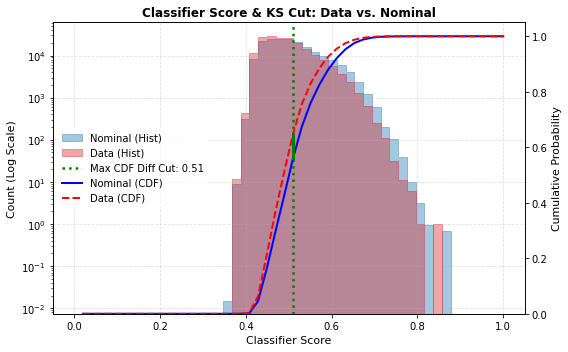

The maximum CDF difference is 0.0873 at a classifier score of 0.5102


In [6]:
nom_cut_cdf = bkg_score_plot(df_data, df_mc_rw, "score_vs_nominal", "score_vs_data", "final_weight")

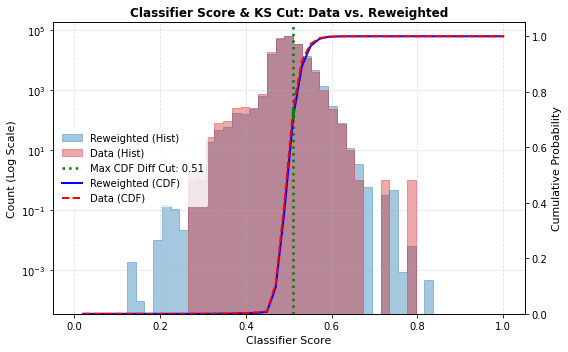

The maximum CDF difference is 0.0317 at a classifier score of 0.5102


In [7]:
rw_cut_cdf = bkg_score_plot(df_data, df_mc_rw, "score_vs_reweighted", "score_vs_reweighted_data", "rw_mediam_weights")

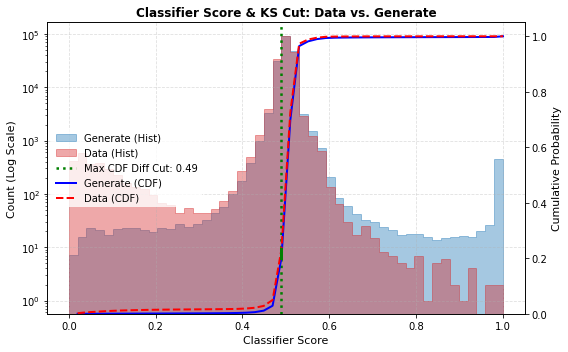

The maximum CDF difference is 0.0304 at a classifier score of 0.4898


In [8]:
gen_cut_cdf = bkg_score_plot(df_data, df_mc_gen, "score_vs_generate", "score_vs_data", "total_weight")

In [9]:
SIGNAL_MODES = [
    "1000_2",
    "1000_4",
    "1000_6",
    "1000_8",
    "2000_2",
    "2000_4",
    "2000_6",
    "2000_8",
    "3000_2",
    "3000_4",
    "3000_6",
    "3000_8"
]

In [10]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

Loading Signal: 1000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_2_default.parquet
  -> Loaded 3027 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 7338.88 events.
Loading Signal: 1000_4... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_4_default.parquet
  -> Loaded 6949 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 16828.26 events.
Loading Signal: 1000_6... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_6_default.parquet
  -> Loaded 11480 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 27835.87 events.
Loading Signal: 1000_8... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2/SR/bsm_1000_8_default.parquet
  -> Loaded 16409 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 39795.68 events.
Loading Signal: 2000_2... from /home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_v

In [11]:
detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

In [12]:
def plot_sig_kin(df_data, df_bkg, df_sig, bkg_type, sig_mode):

    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    row1_vars = ['ht', 'met', 'score']
    row2_vars = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

    log_vars = ['mjj', 'ht', 'met', 'score']
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'score': f'Anomaly Score ({bkg_type})',
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    fig = plt.figure(figsize=(24, 12))

    gs_outer = fig.add_gridspec(2, 1, hspace=0.35)

    gs_top = gs_outer[0].subgridspec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.25)
    gs_bot = gs_outer[1].subgridspec(2, 5, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    def draw_variable(var, gs_inner, col_idx):
        if var == "score":
            density = True
            bins = np.arange(0, 1, 1/50)
        else:
            density = False
            bins = np.arange(-3, 3, 0.25)
        d_col = data_col_score if var == 'score' else var
        b_col = bkg_col_score if var == 'score' else var
        s_col = sig_col_score if var == 'score' else var
        
        var_name = var
        if d_col not in df_data.columns and var == 'met' and 'met_recalc_pt' in df_data.columns:
            d_col, b_col, s_col = 'met_recalc_pt', 'met_recalc_pt', 'met_recalc_pt'
            var_name = 'met_recalc_pt'

        data_arr = df_data[d_col].to_numpy()
        bkg_arr = df_bkg[b_col].to_numpy()
        sig_arr = df_sig[s_col].to_numpy()
        bkg_weights = df_bkg[bkg_weight_name].to_numpy()
        sig_weights = df_sig["final_weight"]

        bin_centers = (bins[:-1] + bins[1:]) / 2

        ax_main = fig.add_subplot(gs_inner[0, col_idx])
        ax_ratio = fig.add_subplot(gs_inner[1, col_idx], sharex=ax_main)

        # --- DATA ---
        counts_data, _ = np.histogram(data_arr, bins=bins, density=density)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        valid = counts_data > 0
        
        if var == "score":
            ax_main.errorbar(bin_centers, counts_data, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        else:    
            ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Data', zorder=10, capsize=0, markersize=4)
            data_ratio_err = np.zeros_like(counts_data, dtype=float)
            data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
            ax_ratio.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=4)
            ax_ratio.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # --- BACKGROUND ---
        counts_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights, density=density)
        ax_main.stairs(counts_bkg, bins, fill=True, color="grey", alpha=0.5, label=f'SM Background')
        
        ratio_bkg = np.divide(counts_bkg, counts_data, out=np.full_like(counts_bkg, np.nan, dtype=float), where=valid)
        ax_ratio.stairs(ratio_bkg, bins, color="grey", alpha=0.8)

        # --- SIGNAL ---
        counts_sig, _ = np.histogram(sig_arr, bins=bins, weights=sig_weights, density=density)
        ax_main.stairs(counts_sig, bins, color="red", linewidth=2, linestyle='-', label='Signal (BSM)')


        # if var in log_vars:
        ax_main.set_yscale('log')

        ymin, ymax = ax_main.get_ylim()
        if var in log_vars:

            ax_main.set_ylim(ymin, ymax) 
        else:
            ax_main.set_ylim(ymin, ymax * 1.5)

        if col_idx == 0:
            ax_main.set_ylabel('Events', fontsize=12)
            ax_ratio.set_ylabel('Bkg/Data', fontsize=10)
        
        ax_main.legend(frameon=False, fontsize=9, loc='upper right')
        plt.setp(ax_main.get_xticklabels(), visible=False) # Hide x-ticks on main plot

        ax_ratio.set_ylim(0.5, 1.5) 
        ax_ratio.set_xlabel(pretty_labels.get(var_name, var_name), fontsize=12)
        ax_ratio.tick_params(axis='x', which='both', bottom=True, top=True)
        ax_ratio.grid(True, axis='y', linestyle=':', alpha=0.6)


    for i, var in enumerate(row1_vars):
        draw_variable(var, gs_top, i)
        

    for i, var in enumerate(row2_vars):
        draw_variable(var, gs_bot, i)

    title_text = (
        r"Kinematic Distributions ($M_\phi = "
        + str(sig_mode.split("_")[0])
        + r"\text{ GeV}$, $R_{\text{inv}} = 0."
        + str(sig_mode.split("_")[1])
        + r"$)"
    )

    fig.suptitle(title_text, fontsize=20, fontweight="bold", y=0.95)
    plt.show()

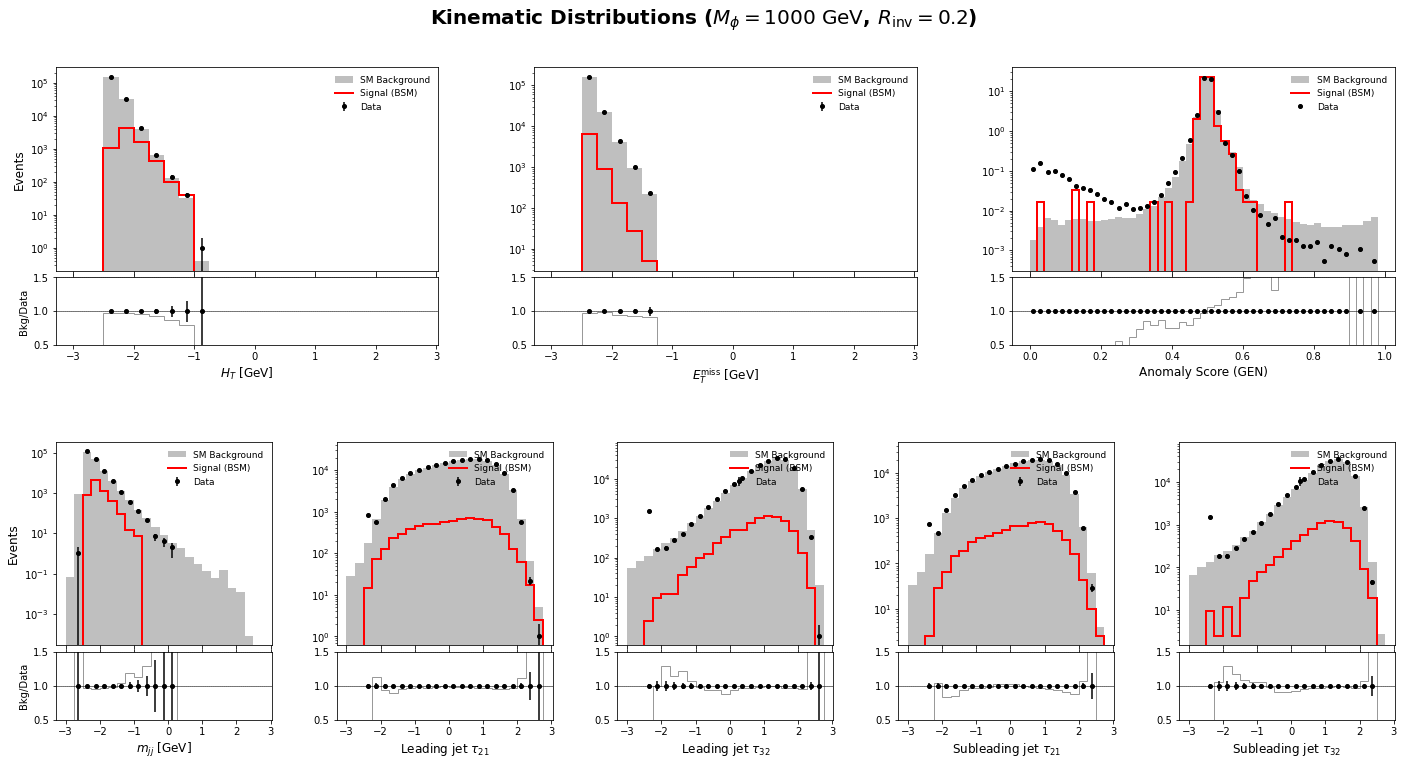

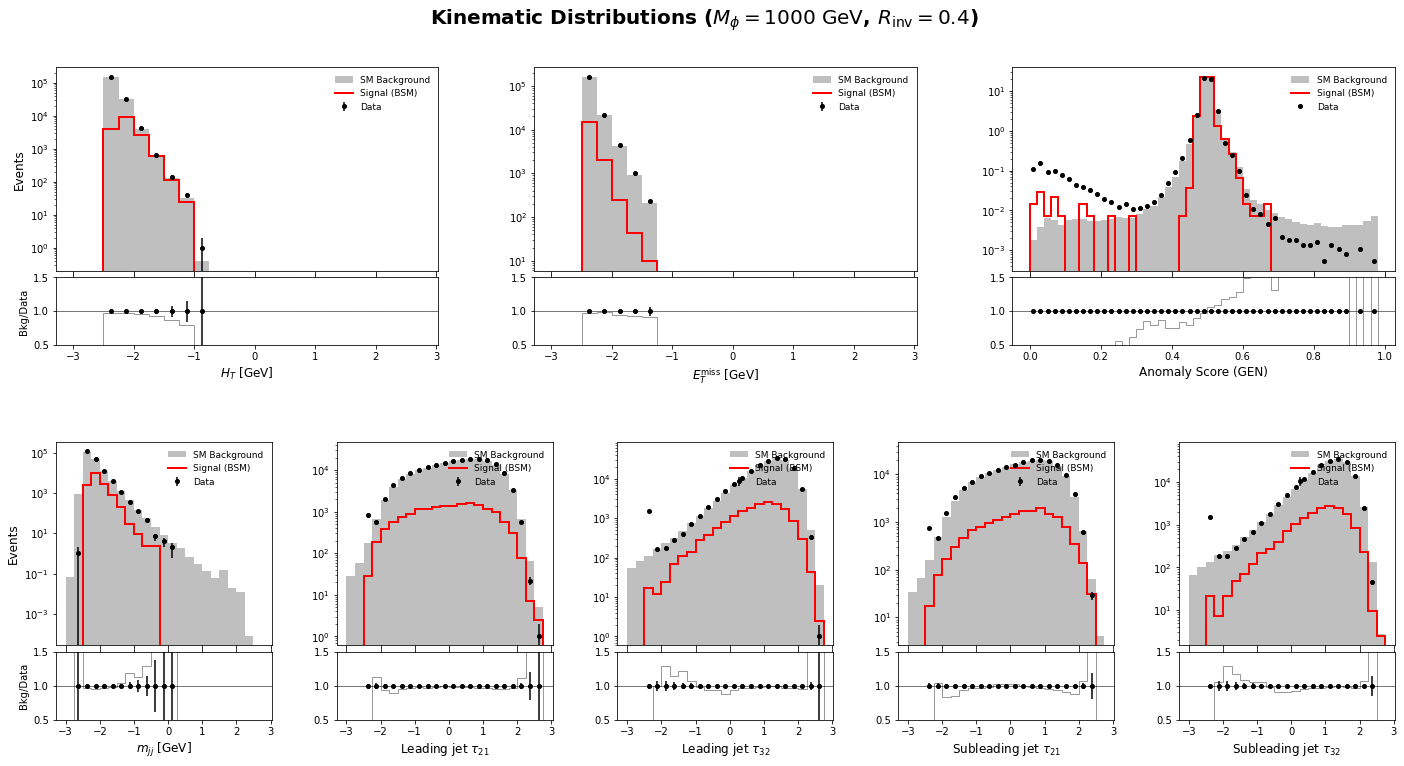

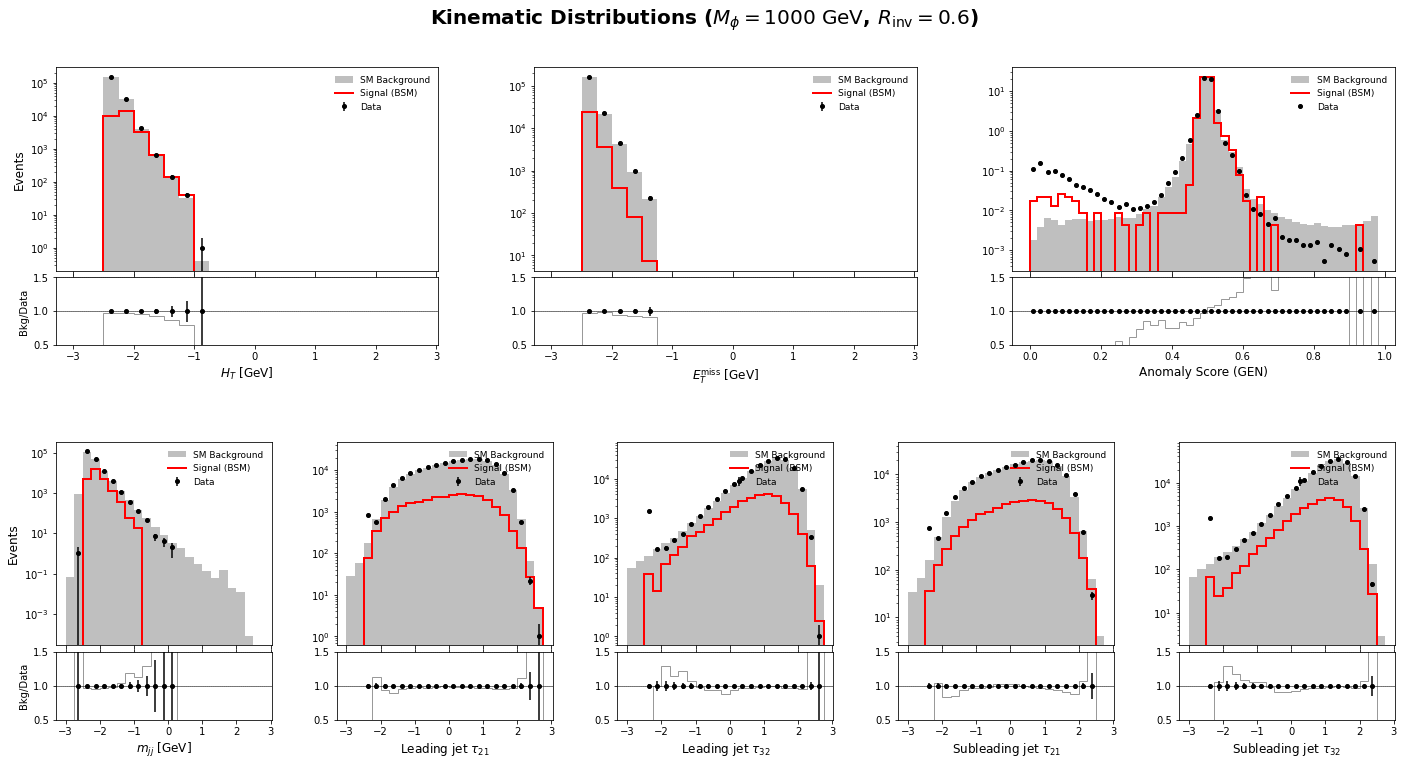

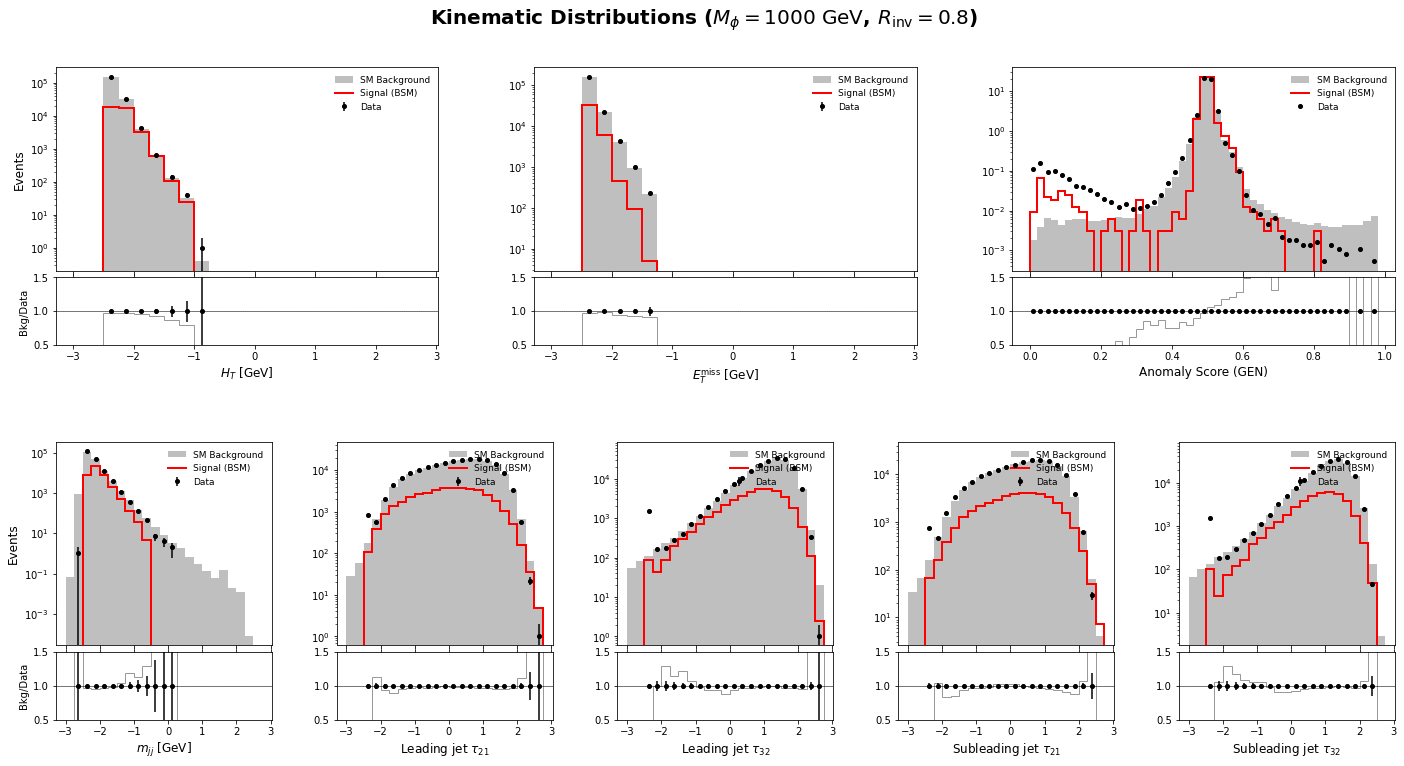

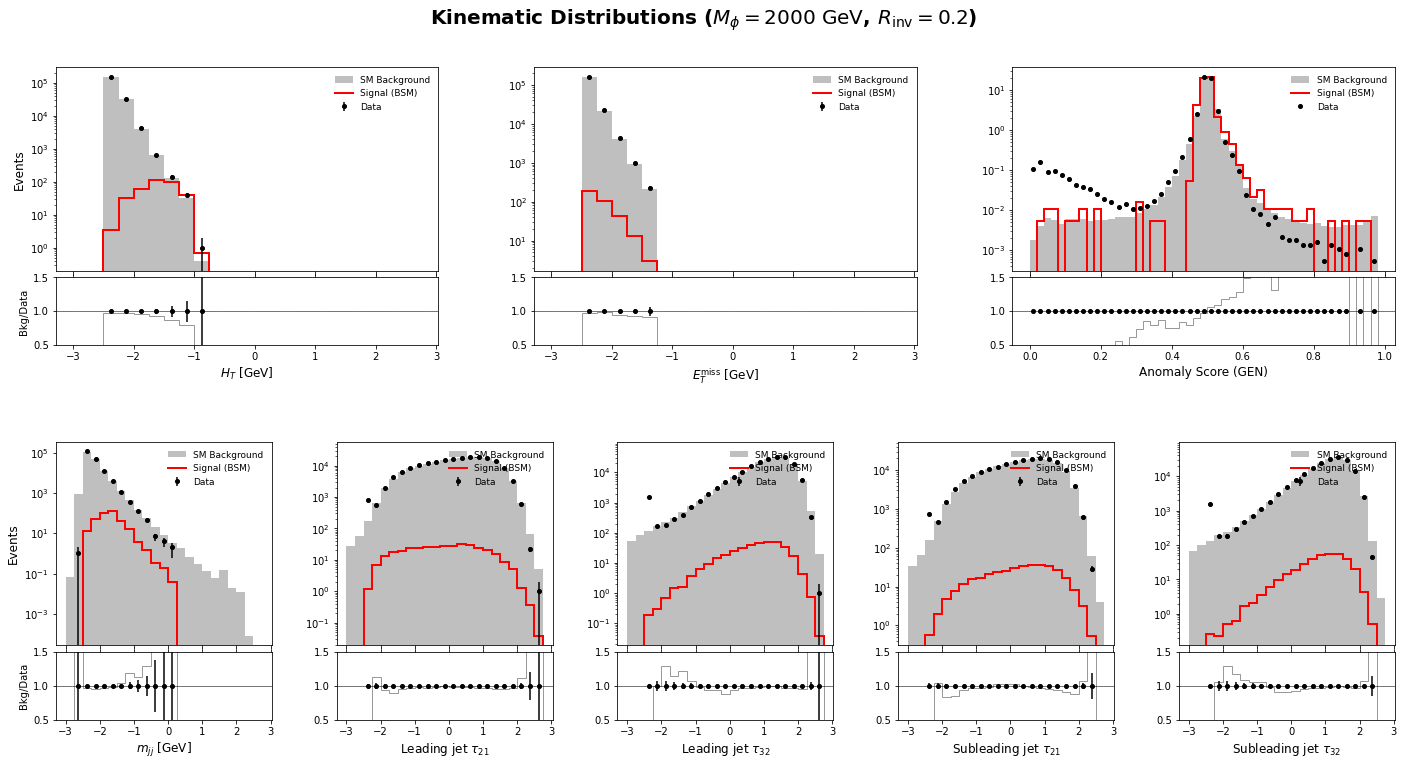

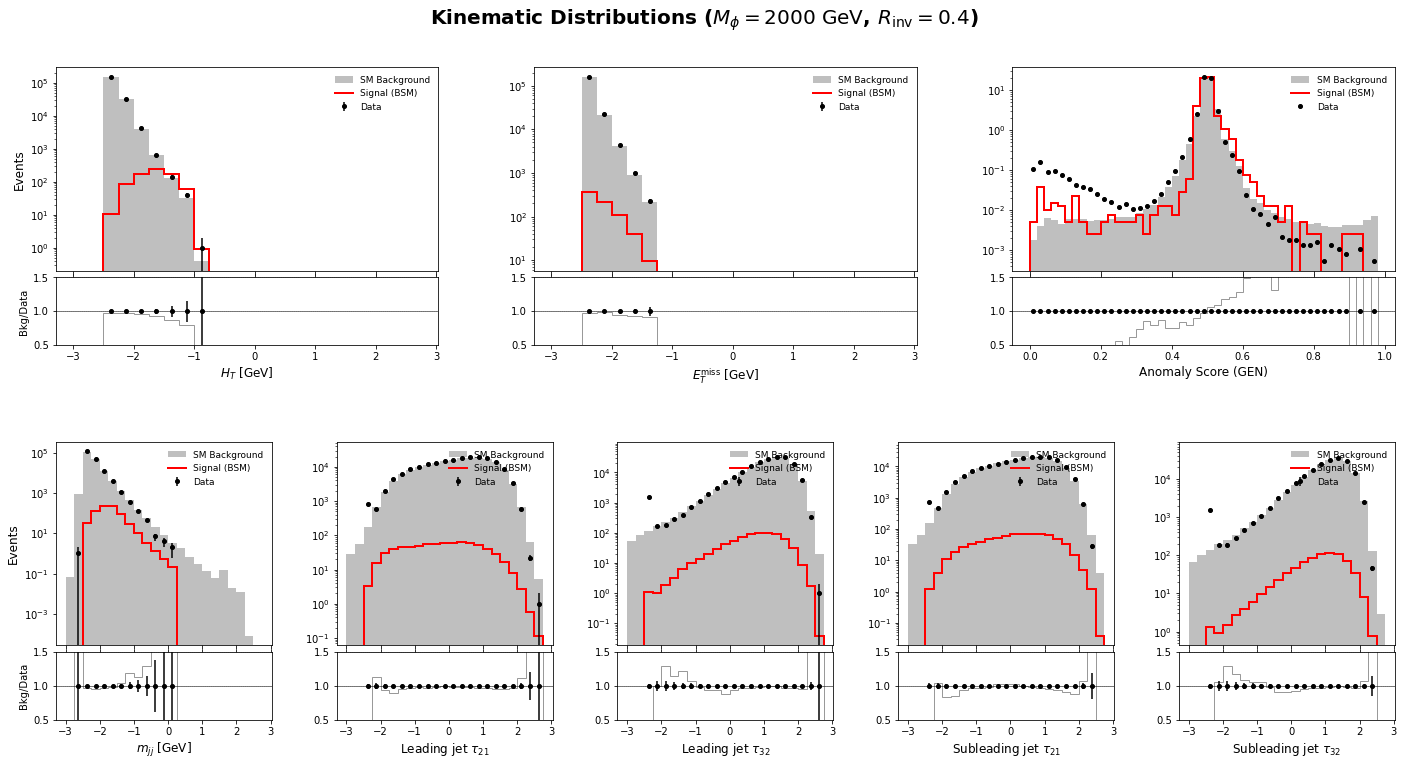

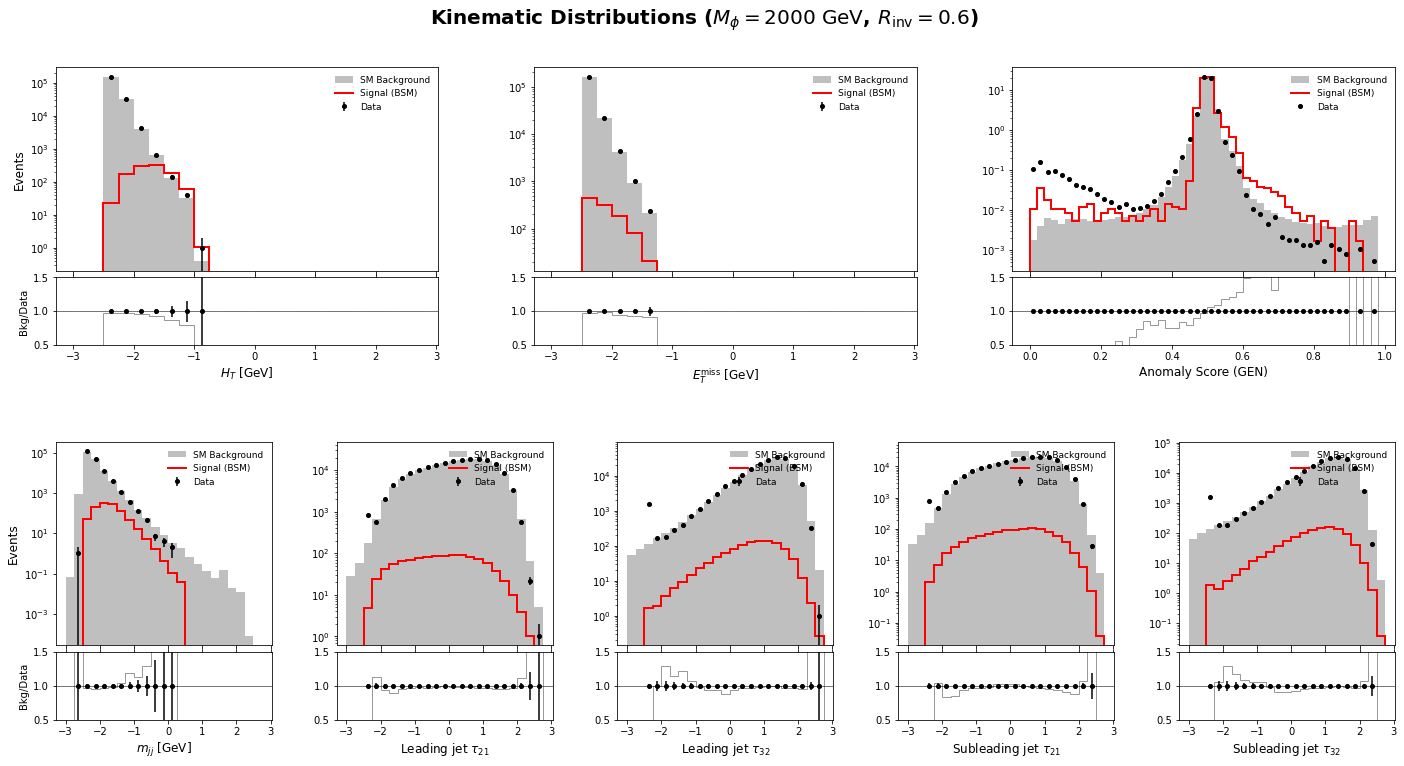

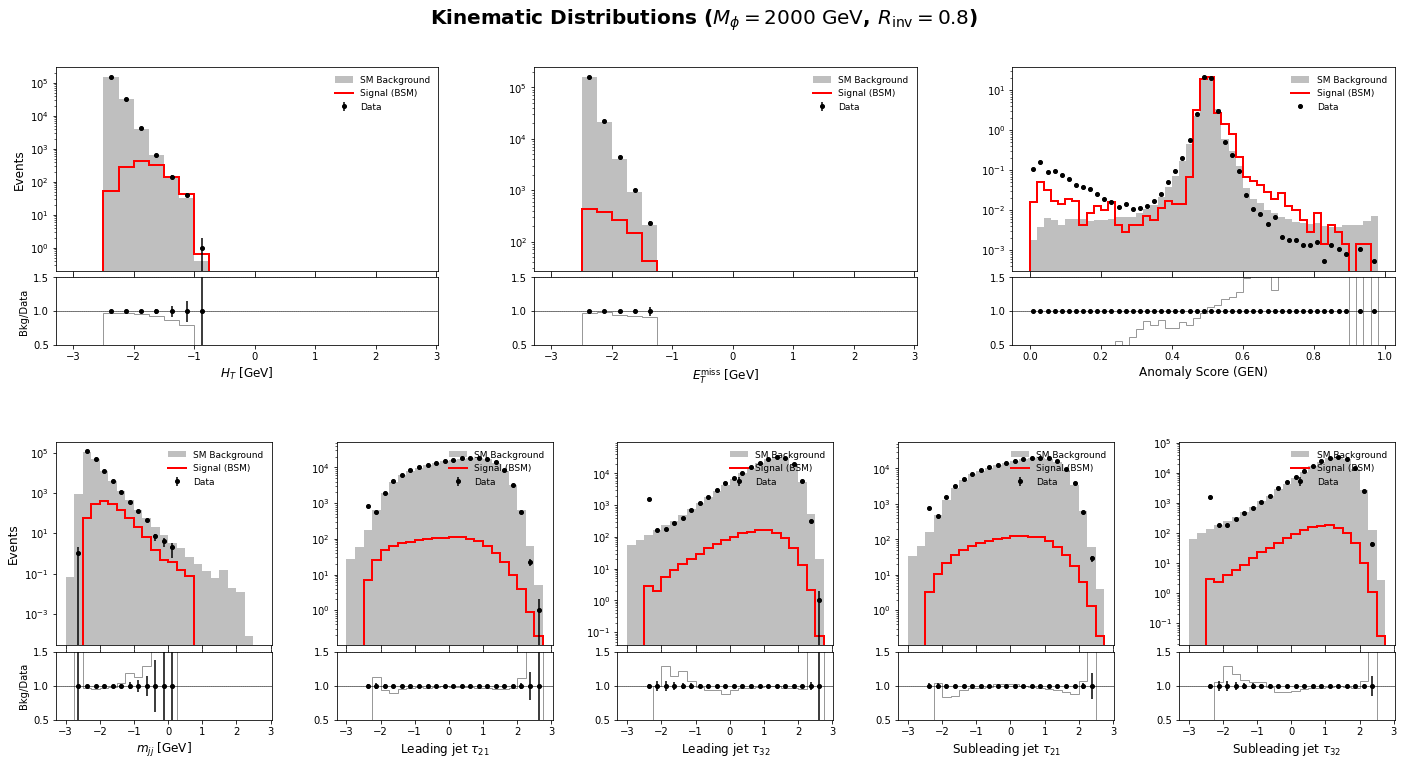

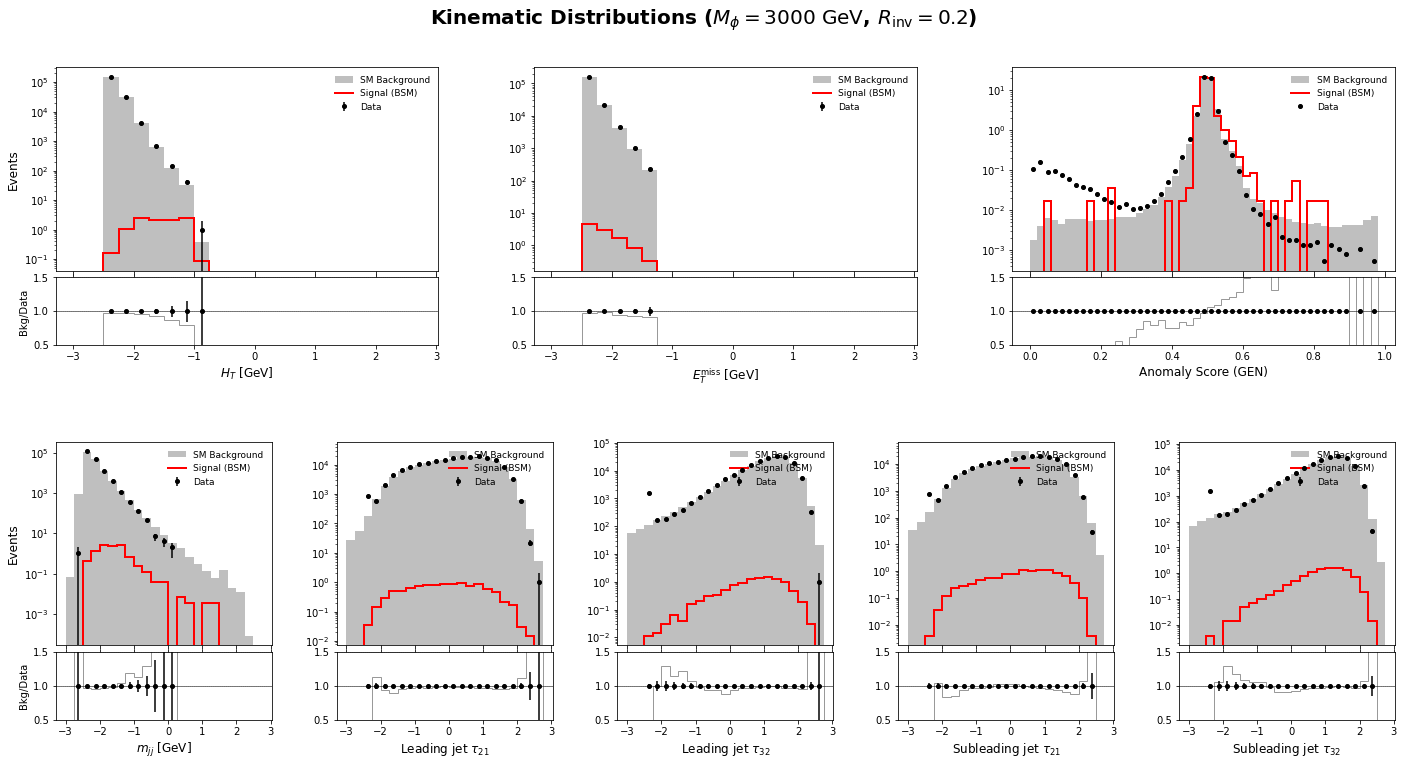

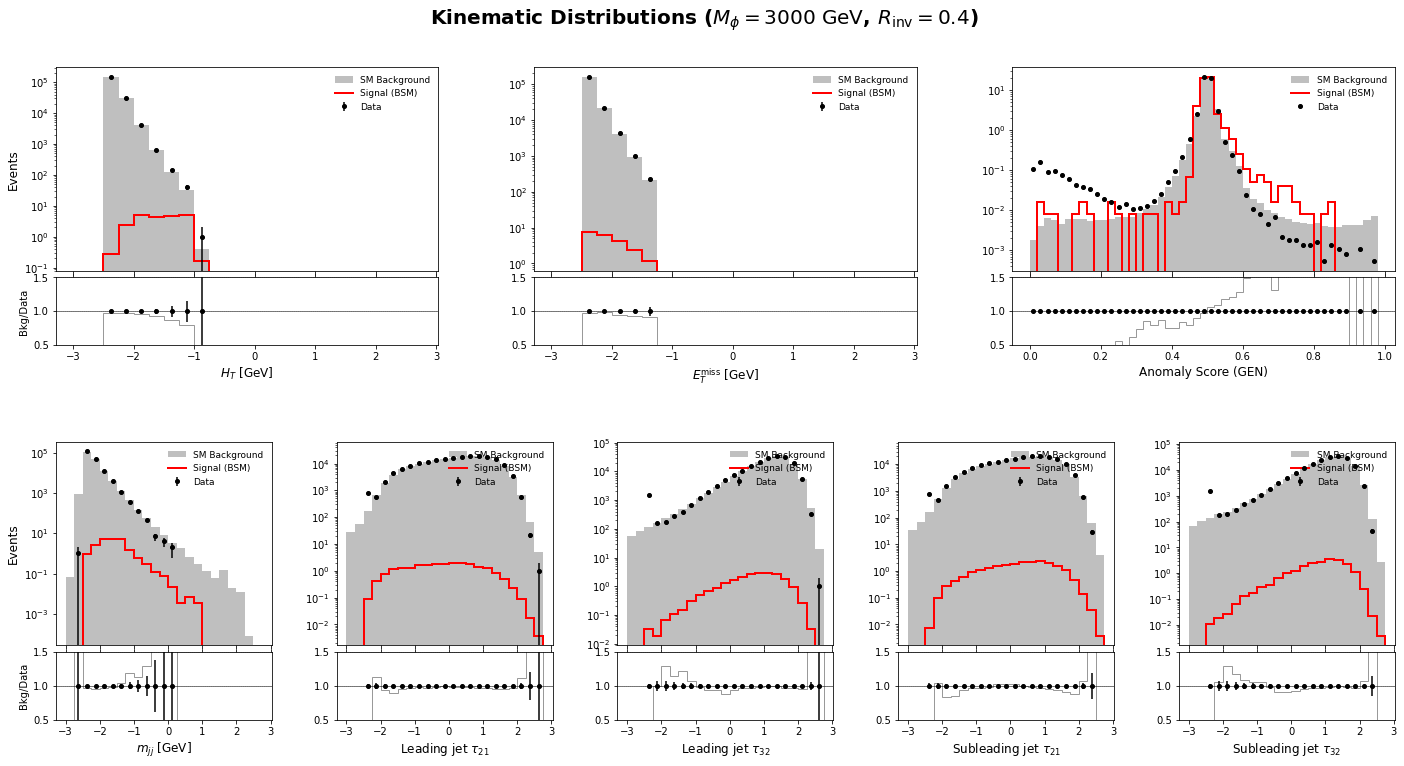

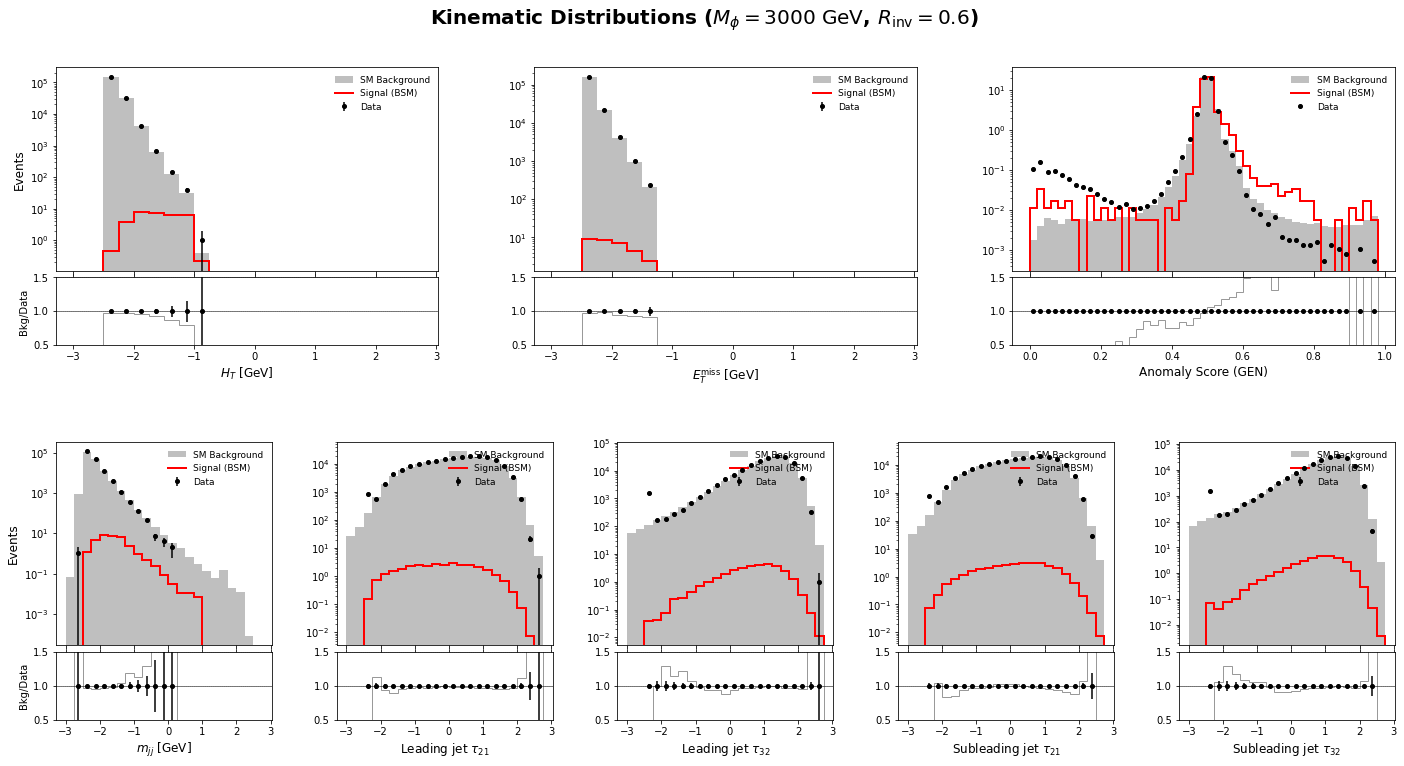

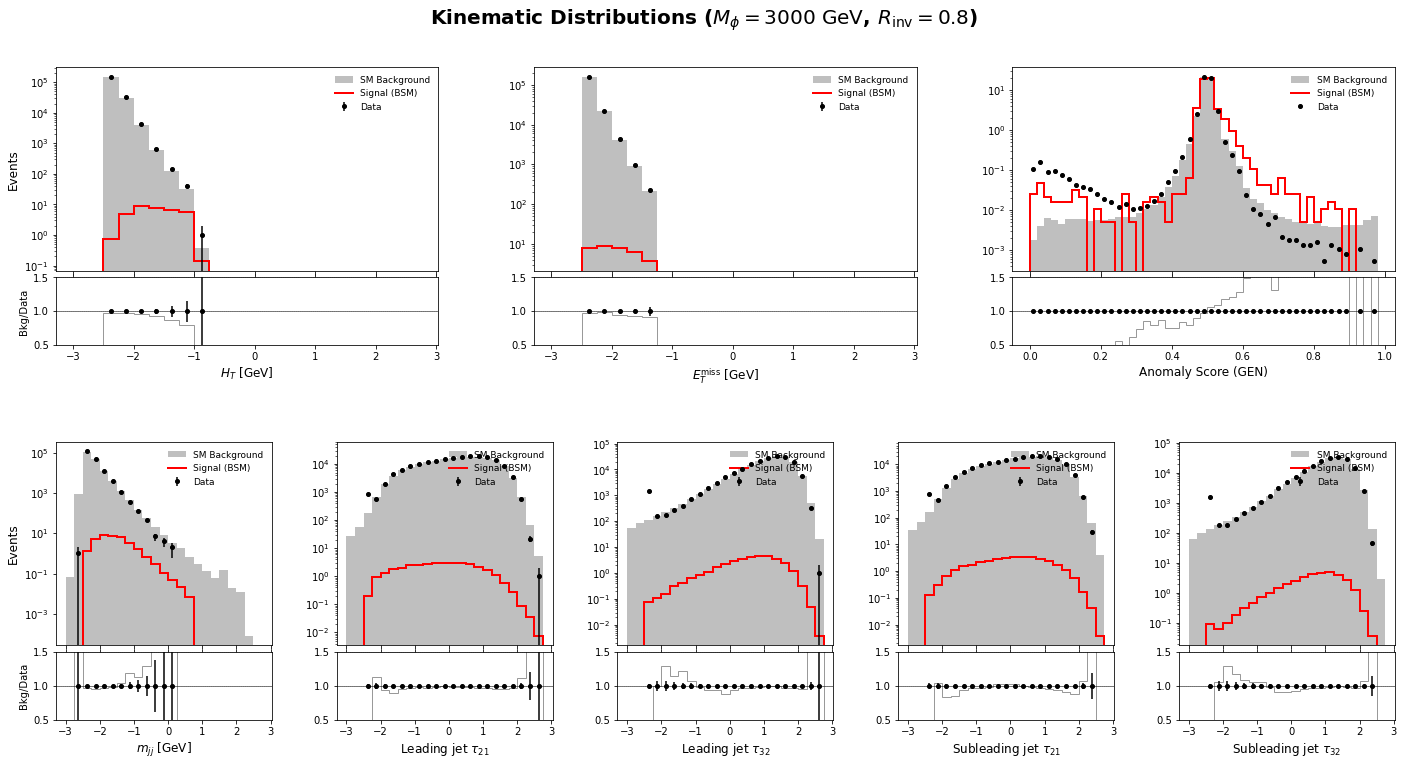

In [13]:
bkg_type = "GEN" # NOM, RW, GEN

for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
    else:
        df_mc = df_mc_rw
    plot_sig_kin(df_data, df_mc, df_sig_def[sig_mode], bkg_type=bkg_type, sig_mode = sig_mode)

In [14]:
# def plot_sr_closure(df_data, df_bkg, bkg_type, features, threshold):
#     # 1. Determine labels and columns based on background type
#     if bkg_type == "NOM":
#         data_col_score = "score_vs_nominal"
#         bkg_col_score = "score_vs_data"
#         bkg_weight_name = "final_weight"
#         bkg_label = "Nominal MC"
#         color = "#1f77b4" # Blue
#     elif bkg_type == "RW":
#         data_col_score = "score_vs_reweighted"
#         bkg_col_score = "score_vs_reweighted_data"
#         bkg_weight_name = "rw_mediam_weights"
#         bkg_label = "Reweighted (SALAD-like)"
#         color = "#2ca02c" # Green
#     elif bkg_type == "GEN":
#         data_col_score = "score_vs_generate"
#         bkg_col_score = "score_vs_data"
#         bkg_weight_name = "total_weight"
#         bkg_label = "Generated (CATHODE-like)"
#         color = "#ff7f0e" # Orange
#     else:
#         raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

#     # 2. Filter events ONCE for all features
#     data_events = df_data[df_data[data_col_score] > threshold]
#     bkg_events = df_bkg[df_bkg[bkg_col_score] > threshold]

#     num_features = len(features)
    
#     # 3. Create a 2 x N grid of subplots
#     # squeeze=False ensures `axes` is always a 2D array, even if there's only 1 feature
#     # sharex='col' shares the x-axis between the main plot and ratio plot in the same column
#     fig, axes = plt.subplots(
#         2, num_features, 
#         figsize=(6 * num_features, 7), 
#         sharex='col', 
#         gridspec_kw={'height_ratios': [3, 1]},
#         squeeze=False 
#     )

#     # Set an overall title for the entire figure
#     fig.suptitle(f"High Anomaly Score (SR) Validation ({bkg_type})", fontsize=14, fontweight="bold")

#     # 4. Loop through each feature and plot in its respective column
#     wd_list = []

#     for i, feature in enumerate(features):
#         ax1 = axes[0, i] # Top row (Main plot)
#         ax2 = axes[1, i] # Bottom row (Ratio plot)

#         f_data = data_events[feature].dropna().values
#         f_bkg = bkg_events[feature].dropna().values
#         w_bkg = bkg_events[bkg_weight_name].loc[bkg_events[feature].dropna().index].values

#         valid_range = (-3.0, 3.0)
        
#         data_mask = (f_data >= valid_range[0]) & (f_data <= valid_range[1])
#         f_data_clean = f_data[data_mask]
        
#         bkg_mask = (f_bkg >= valid_range[0]) & (f_bkg <= valid_range[1])
#         f_bkg_clean = f_bkg[bkg_mask]
#         w_bkg_clean = w_bkg[bkg_mask]

#         wd = wasserstein_distance(
#             f_data_clean, 
#             f_bkg_clean, 
#             u_weights=None, 
#             v_weights=np.abs(w_bkg_clean)
#         )

#         wd_list.append(wd)

#         bin_edges = np.arange(-3.0, 3.0, 0.25)
#         bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#         counts_data, _ = np.histogram(f_data, bins=bin_edges)
#         counts_bkg, _ = np.histogram(f_bkg, bins=bin_edges, weights=w_bkg)

#         err_data = np.sqrt(counts_data)
#         err_bkg = np.sqrt(np.histogram(f_bkg, bins=bin_edges, weights=w_bkg**2)[0])

#         # --- Main Plot (ax1) ---
#         ax1.hist(
#             f_bkg, bins=bin_edges, weights=w_bkg,
#             alpha=0.5, color=color, label=bkg_label, histtype="stepfilled"
#         )
#         ax1.errorbar(
#             bin_centers, counts_data, yerr=err_data, 
#             fmt='ko', label=f"Data (Score > {threshold:.3f})", capsize=2, elinewidth=1
#         )
        
#         ax1.text(
#             0.05, 0.95, f"Wasserstein Dist: {wd:.4f}", 
#             transform=ax1.transAxes, fontsize=11, verticalalignment='top', 
#             bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
#         )

#         ax1.set_title(f"Feature: {feature}", fontsize=12)
#         ax1.legend(loc='upper right', frameon=True, fontsize=10)
#         ax1.grid(True, linestyle="--", alpha=0.3)
#         ax1.set_xlim(-3.0, 2.75) 

#         # Only label the y-axis on the leftmost plot to reduce clutter
#         if i == 0:
#             ax1.set_ylabel("Events", fontsize=11)

#         # --- Ratio Plot (ax2) ---
#         ratio = np.divide(counts_data, counts_bkg, out=np.zeros_like(counts_data, dtype=float), where=counts_bkg!=0)
#         ratio_err = np.divide(err_data, np.abs(counts_bkg), out=np.zeros_like(err_data, dtype=float), where=counts_bkg!=0)

#         ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=2, elinewidth=1)
#         ax2.axhline(1.0, color='red', linestyle='--', alpha=0.7) 
#         ax2.set_xlabel(feature, fontsize=11)
#         ax2.set_ylim(0.5, 1.5) 
#         ax2.grid(True, linestyle="--", alpha=0.3)

#         # Only label the y-axis on the leftmost ratio plot
#         if i == 0:
#             ax2.set_ylabel("Data / Bkg", fontsize=10)

#     plt.tight_layout()
#     plt.show()

# 1. Determine labels and columns based on background type
def plot_sr_closure(df_data, df_bkg, bkg_type, features):
    if bkg_type == "NOM":
        data_col_score = "score_vs_nominal"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "final_weight"
        bkg_label = "Nominal MC"
        color = "#1f77b4" # Blue
    elif bkg_type == "RW":
        data_col_score = "score_vs_reweighted"
        bkg_col_score = "score_vs_reweighted_data"
        bkg_weight_name = "rw_mediam_weights"
        bkg_label = "Reweighted (SALAD-like)"
        color = "#2ca02c" # Green
    elif bkg_type == "GEN":
        data_col_score = "score_vs_generate"
        bkg_col_score = "score_vs_data"
        bkg_weight_name = "total_weight"
        bkg_label = "Generated (CATHODE-like)"
        color = "#ff7f0e" # Orange
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Scan through all thresholds to find the one with the min average WD
    best_threshold = None
    min_avg_wd = float('inf')
    best_wd_list = []
    thresholds = np.linspace(0, 1, 50)
    print(f"Scanning {len(thresholds)} thresholds...")
    for thresh in thresholds:
        data_events = df_data[df_data[data_col_score] > thresh]
        bkg_events = df_bkg[df_bkg[bkg_col_score] > thresh]
        
        current_wds = []
        for feature in features:
            f_data = data_events[feature].dropna().values
            f_bkg = bkg_events[feature].dropna().values
            w_bkg = bkg_events[bkg_weight_name].loc[bkg_events[feature].dropna().index].values

            valid_range = (-3.0, 3.0)
            
            data_mask = (f_data >= valid_range[0]) & (f_data <= valid_range[1])
            f_data_clean = f_data[data_mask]
            
            bkg_mask = (f_bkg >= valid_range[0]) & (f_bkg <= valid_range[1])
            f_bkg_clean = f_bkg[bkg_mask]
            w_bkg_clean = w_bkg[bkg_mask]

            # Protect against empty arrays if a threshold cuts all events
            if len(f_data_clean) == 0 or len(f_bkg_clean) == 0:
                wd = float('inf') 
            else:
                wd = wasserstein_distance(
                    f_data_clean, 
                    f_bkg_clean, 
                    u_weights=None, 
                    v_weights=np.abs(w_bkg_clean)
                )
            current_wds.append(wd)
            
        avg_wd = np.mean(current_wds)
        
        if avg_wd < min_avg_wd:
            min_avg_wd = avg_wd
            best_threshold = thresh
            best_wd_list = current_wds

    print(f"Optimal threshold found: {best_threshold:.4f} (Average WD: {min_avg_wd:.4f})")

    # 3. Filter events ONCE using the best threshold
    data_events = df_data[df_data[data_col_score] > best_threshold]
    bkg_events = df_bkg[df_bkg[bkg_col_score] > best_threshold]

    num_features = len(features)
    
    # 4. Create a 2 x N grid of subplots
    fig, axes = plt.subplots(
        2, num_features, 
        figsize=(6 * num_features, 7), 
        sharex='col', 
        gridspec_kw={'height_ratios': [3, 1]},
        squeeze=False 
    )

    # Update title to indicate this is the optimal threshold
    fig.suptitle(
        f"High Anomaly Score (SR) Validation ({bkg_type})\n"
        f"Plotted at Optimal Threshold: {best_threshold:.3f} (Avg WD: {min_avg_wd:.4f})", 
        fontsize=14, fontweight="bold"
    )

    # 5. Loop through each feature and plot
    for i, feature in enumerate(features):
        ax1 = axes[0, i] # Top row (Main plot)
        ax2 = axes[1, i] # Bottom row (Ratio plot)

        f_data = data_events[feature].dropna().values
        f_bkg = bkg_events[feature].dropna().values
        w_bkg = bkg_events[bkg_weight_name].loc[bkg_events[feature].dropna().index].values
        
        # We don't need to recalculate WD; we just pull it from best_wd_list
        wd = best_wd_list[i]
        
        bin_edges = np.arange(-3.0, 3.0, 0.25)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        counts_data, _ = np.histogram(f_data, bins=bin_edges)
        counts_bkg, _ = np.histogram(f_bkg, bins=bin_edges, weights=w_bkg)

        err_data = np.sqrt(counts_data)
        err_bkg = np.sqrt(np.histogram(f_bkg, bins=bin_edges, weights=w_bkg**2)[0])

        # --- Main Plot (ax1) ---
        ax1.hist(
            f_bkg, bins=bin_edges, weights=w_bkg,
            alpha=0.5, color=color, label=bkg_label, histtype="stepfilled"
        )
        ax1.errorbar(
            bin_centers, counts_data, yerr=err_data, 
            fmt='ko', label=f"Data (Score > {best_threshold:.3f})", capsize=2, elinewidth=1
        )
        
        ax1.text(
            0.05, 0.95, f"Wasserstein Dist: {wd:.4f}", 
            transform=ax1.transAxes, fontsize=11, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9)
        )

        ax1.set_title(f"Feature: {feature}", fontsize=12)
        ax1.legend(loc='upper right', frameon=True, fontsize=10)
        ax1.grid(True, linestyle="--", alpha=0.3)
        ax1.set_xlim(-3.0, 2.75) 

        # Only label the y-axis on the leftmost plot to reduce clutter
        if i == 0:
            ax1.set_ylabel("Events", fontsize=11)

        # --- Ratio Plot (ax2) ---
        ratio = np.divide(counts_data, counts_bkg, out=np.zeros_like(counts_data, dtype=float), where=counts_bkg!=0)
        ratio_err = np.divide(err_data, np.abs(counts_bkg), out=np.zeros_like(err_data, dtype=float), where=counts_bkg!=0)

        ax2.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=2, elinewidth=1)
        ax2.axhline(1.0, color='red', linestyle='--', alpha=0.7) 
        ax2.set_xlabel(feature, fontsize=11)
        ax2.set_ylim(0.5, 1.5) 
        ax2.grid(True, linestyle="--", alpha=0.3)

        # Only label the y-axis on the leftmost ratio plot
        if i == 0:
            ax2.set_ylabel("Data / Bkg", fontsize=10)

    plt.tight_layout()
    plt.show()
    return best_threshold

Scanning 50 thresholds...
Optimal threshold found: 0.6122 (Average WD: 0.0175)


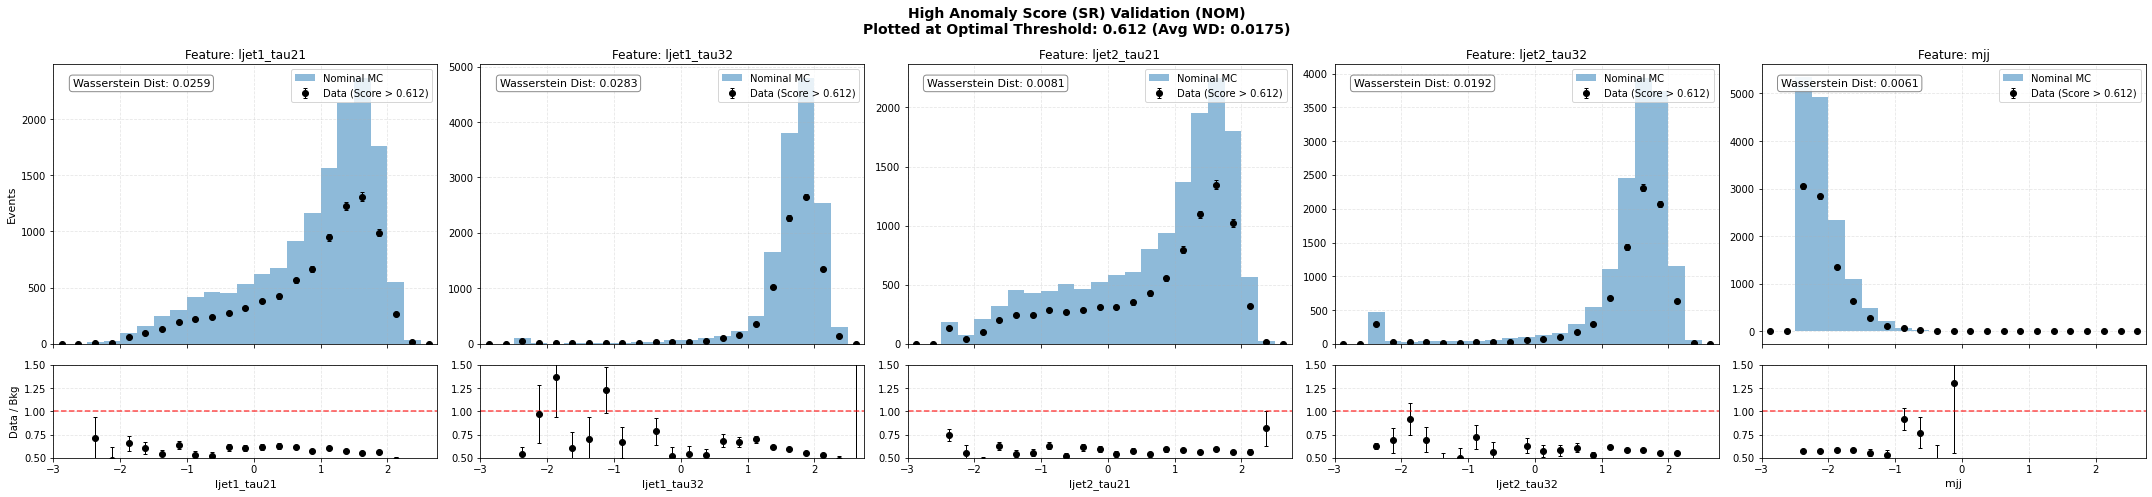

Scanning 50 thresholds...
Optimal threshold found: 0.5102 (Average WD: 0.0094)


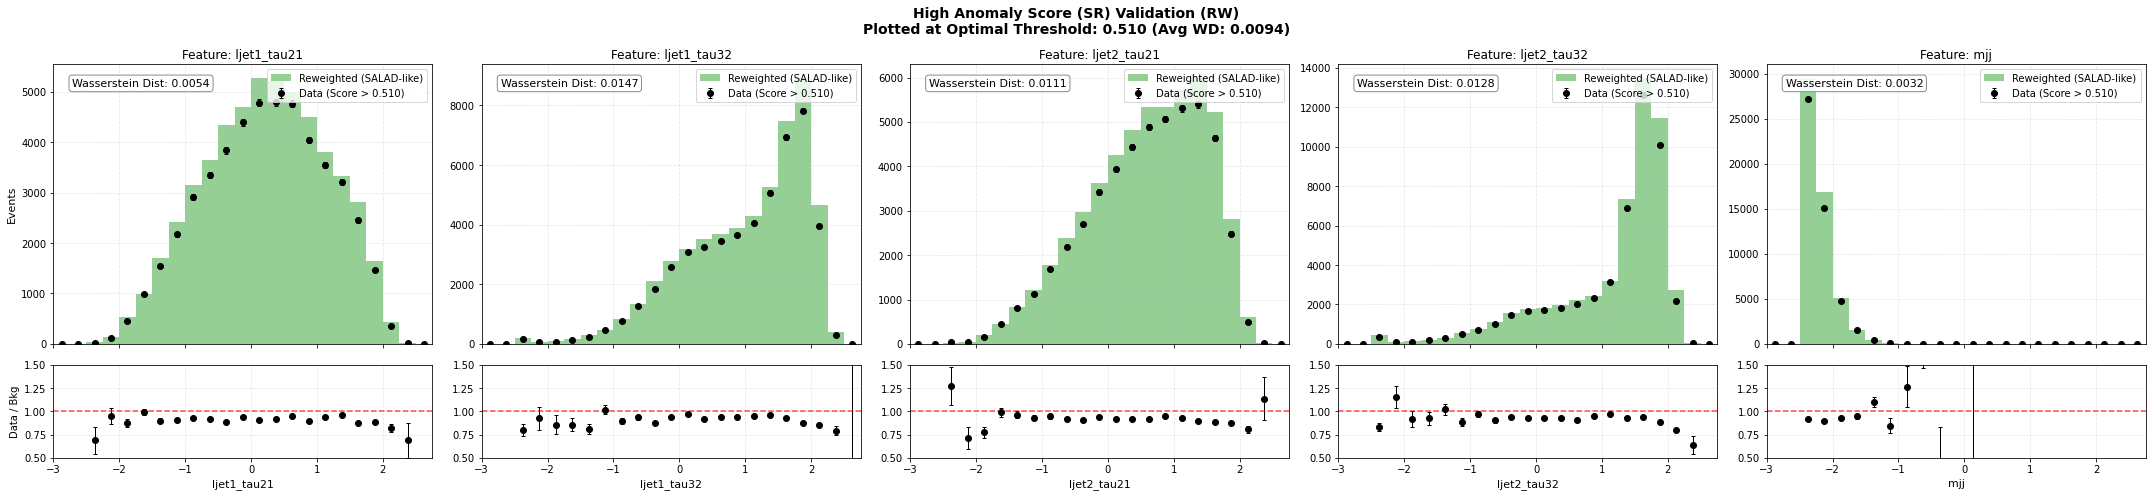

Scanning 50 thresholds...
Optimal threshold found: 0.1633 (Average WD: 0.0098)


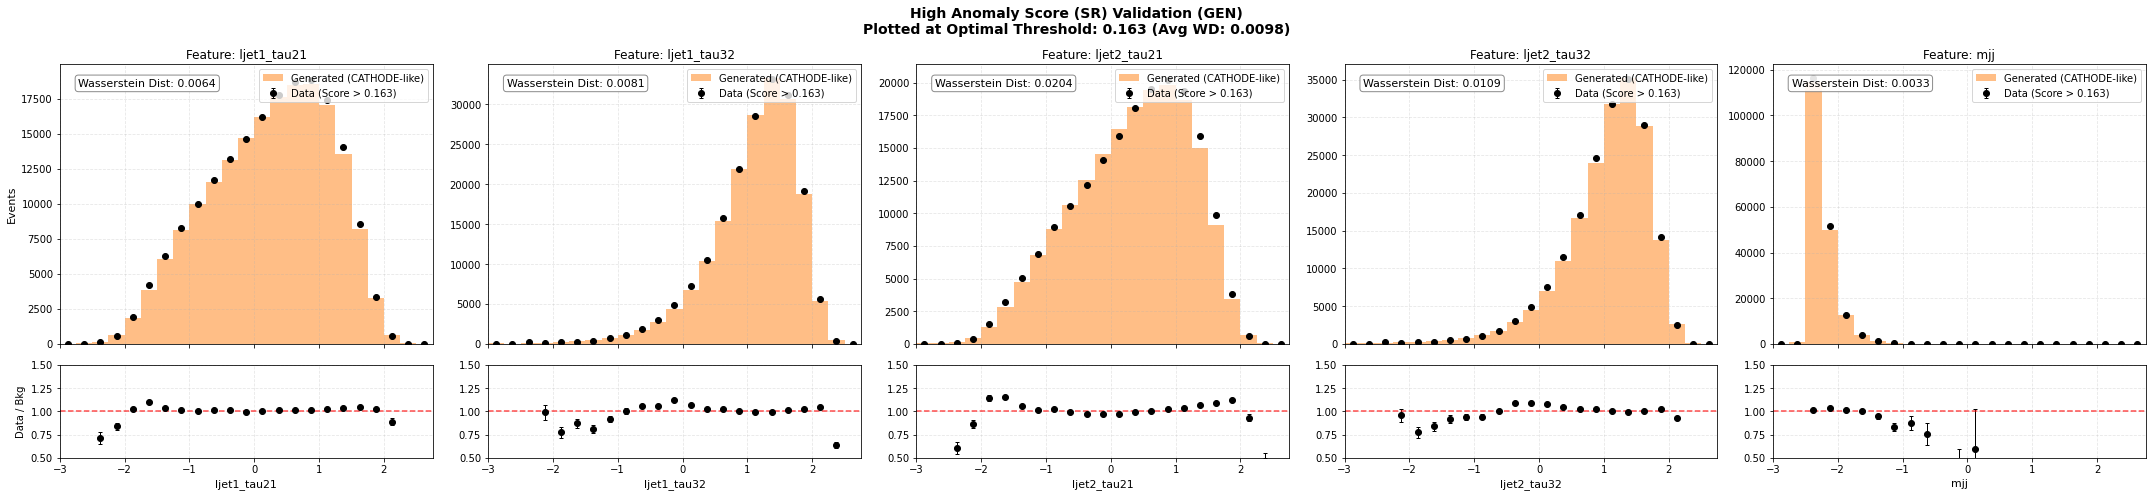

In [15]:
# for feat in features_vars:
nom_cut = plot_sr_closure(df_data, df_mc_rw, bkg_type="NOM", features=features_vars)
rw_cut = plot_sr_closure(df_data, df_mc_rw, bkg_type="RW", features=features_vars)
gen_cut = plot_sr_closure(df_data, df_mc_gen, bkg_type="GEN", features=features_vars)

In [16]:
def optimize_cut_threshold(df_sig_dict, df_bkg, bkg_type, sig_modes, thres_max):
    """
    df_sig_dict: Dictionary mapping sig_mode strings to their respective DataFrames
    sig_modes: List of strings to plot, e.g., ["500_3", "1000_3", ...]
    """
    if bkg_type == "NOM":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Nom"
        bkg_weight_name = "final_weight"
    elif bkg_type == "RW":
        bkg_col_score = "score_vs_reweighted_data"
        sig_col_score = "bsm_score_Reweight_Median"
        bkg_weight_name = "rw_mediam_weights"
    elif bkg_type == "GEN":
        bkg_col_score = "score_vs_data"
        sig_col_score = "bsm_score_Generate_Combined"
        bkg_weight_name = "total_weight"
    else:
        raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")

    thresholds = np.linspace(0.001, thres_max, 100)
    num_modes = len(sig_modes)
    
    # 1. Pre-calculate background yields
    b_yields = np.zeros(len(thresholds))
    for idx, thresh in enumerate(thresholds):
        b_mask = df_bkg[bkg_col_score] < thresh
        b_yields[idx] = df_bkg.loc[b_mask, bkg_weight_name].sum()

    # 2. Setup dynamic grid: Max 4 columns per row
    cols = min(4, num_modes)
    rows = math.ceil(num_modes / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), squeeze=False)
    fig.suptitle(f"Cut Optimization vs {bkg_type} Background", fontsize=16, fontweight='bold', y=1.02)
    
    # Flatten axes array for easy 1D indexing in the loop
    axes_flat = axes.flatten()
    
    results = {}

    # 3. Loop through each signal mode
    for i, sig_mode in enumerate(sig_modes):
        # Extract the dataframe from the dictionary using the sig_mode key
        df_sig = df_sig_dict[sig_mode] 
        
        mass = sig_mode.split("_")[0]
        rinv = f"0.{sig_mode.split('_')[1]}"
        
        s_yields = np.zeros(len(thresholds))
        significances = np.zeros(len(thresholds))
        
        for idx, thresh in enumerate(thresholds):
            s_mask = df_sig[sig_col_score] < thresh
            S = df_sig.loc[s_mask, "final_weight"].sum()
            B = b_yields[idx]
            
            s_yields[idx] = S
            
            if B > 0 and S > 0:
                significances[idx] = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
            else:
                significances[idx] = 0.0

        max_idx = np.argmax(significances)
        max_Z = significances[max_idx]
        opt_thresh = thresholds[max_idx]
        opt_S = s_yields[max_idx]
        opt_B = b_yields[max_idx]
        
        results[sig_mode] = {
            "mass": mass, "rinv": rinv, "opt_thresh": opt_thresh, 
            "max_Z": max_Z, "opt_S": opt_S, "opt_B": opt_B
        }

        # --- Plotting ---
        ax1 = axes_flat[i]
        
        ax1.plot(thresholds, significances, color='purple', lw=2.5, label=r'Expected Sig (Max: %.2f $\sigma$)' % max_Z)
        ax1.axvline(opt_thresh, color='red', linestyle='--', label=f'Opt Cut: < {opt_thresh:.4f}')
        
        ax1.set_xlabel("Anomaly Score Threshold", fontsize=11)
        
        # Only label the left Y-axis on the first column of every row
        if i % cols == 0:
            ax1.set_ylabel("Significance (Asimov Z)", fontsize=12)
            
        ax1.set_title(f"({mass}, {rinv})", fontsize=14, fontweight='bold')
        ax1.legend(loc='upper left', frameon=True)
        ax1.grid(True, linestyle="--", alpha=0.4)
        
        ax2 = ax1.twinx()
        ax2.plot(thresholds, s_yields, color='blue', linestyle=':', alpha=0.7, label='Signal (S)')
        ax2.plot(thresholds, b_yields, color='orange', linestyle=':', alpha=0.7, label='Bkg (B)')
        
        ax2.set_yscale('log')
        
        # Only label the right Y-axis on the last column of every row, or the very last plot
        if (i % cols == cols - 1) or (i == num_modes - 1):
            ax2.set_ylabel("Expected Event Yield", fontsize=12)
            
        ax2.legend(loc='upper right', frameon=True)

    # 4. Hide any unused subplots (if num_modes is not a perfect multiple of 4)
    for j in range(num_modes, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()
    
    # 5. Print summary
    print("-" * 55)
    print(f"OPTIMAL CUT SUMMARY vs {bkg_type}")
    print("-" * 55)
    for mode, res in results.items():
        print(f"Signal ({res['mass']}, {res['rinv']}):")
        print(f"  Optimal Threshold : < {res['opt_thresh']:.4f}")
        print(f"  Max Significance  : {res['max_Z']:.2f} sigma")
        print(f"  Expected Signal   : {res['opt_S']:.2f}")
        print(f"  Expected Bkg      : {res['opt_B']:.2f}")
        print("-" * 30)
    
    return results

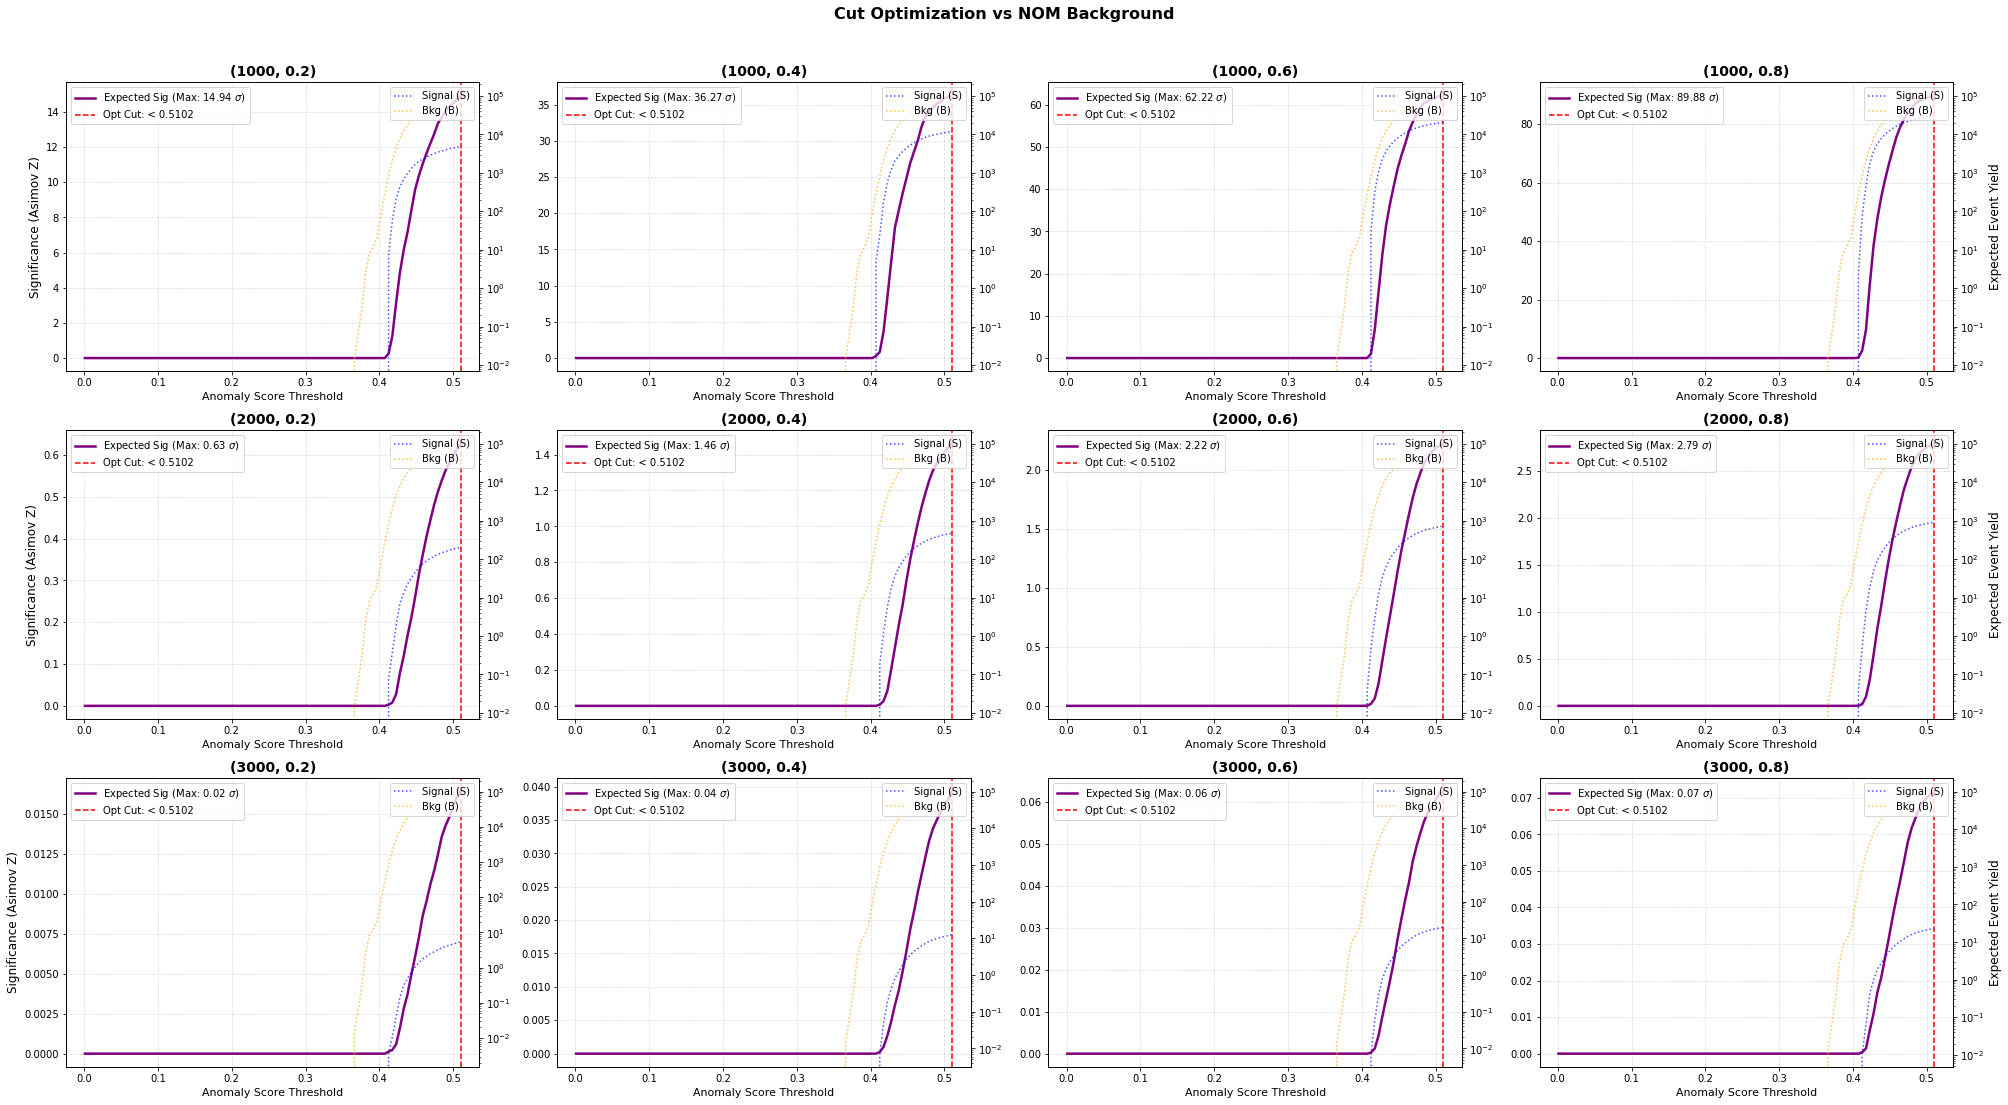

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs NOM
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.5102
  Max Significance  : 14.94 sigma
  Expected Signal   : 4853.80
  Expected Bkg      : 104005.57
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.5102
  Max Significance  : 36.27 sigma
  Expected Signal   : 11914.67
  Expected Bkg      : 104005.57
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.5102
  Max Significance  : 62.22 sigma
  Expected Signal   : 20699.90
  Expected Bkg      : 104005.57
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.5102
  Max Significance  : 89.88 sigma
  Expected Signal   : 30303.31
  Expected Bkg      : 104005.57
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.5102
  Max Significance  : 0.63 sigma
  Expected Signal   : 202.59
  Expected Bkg      : 104005.57
-

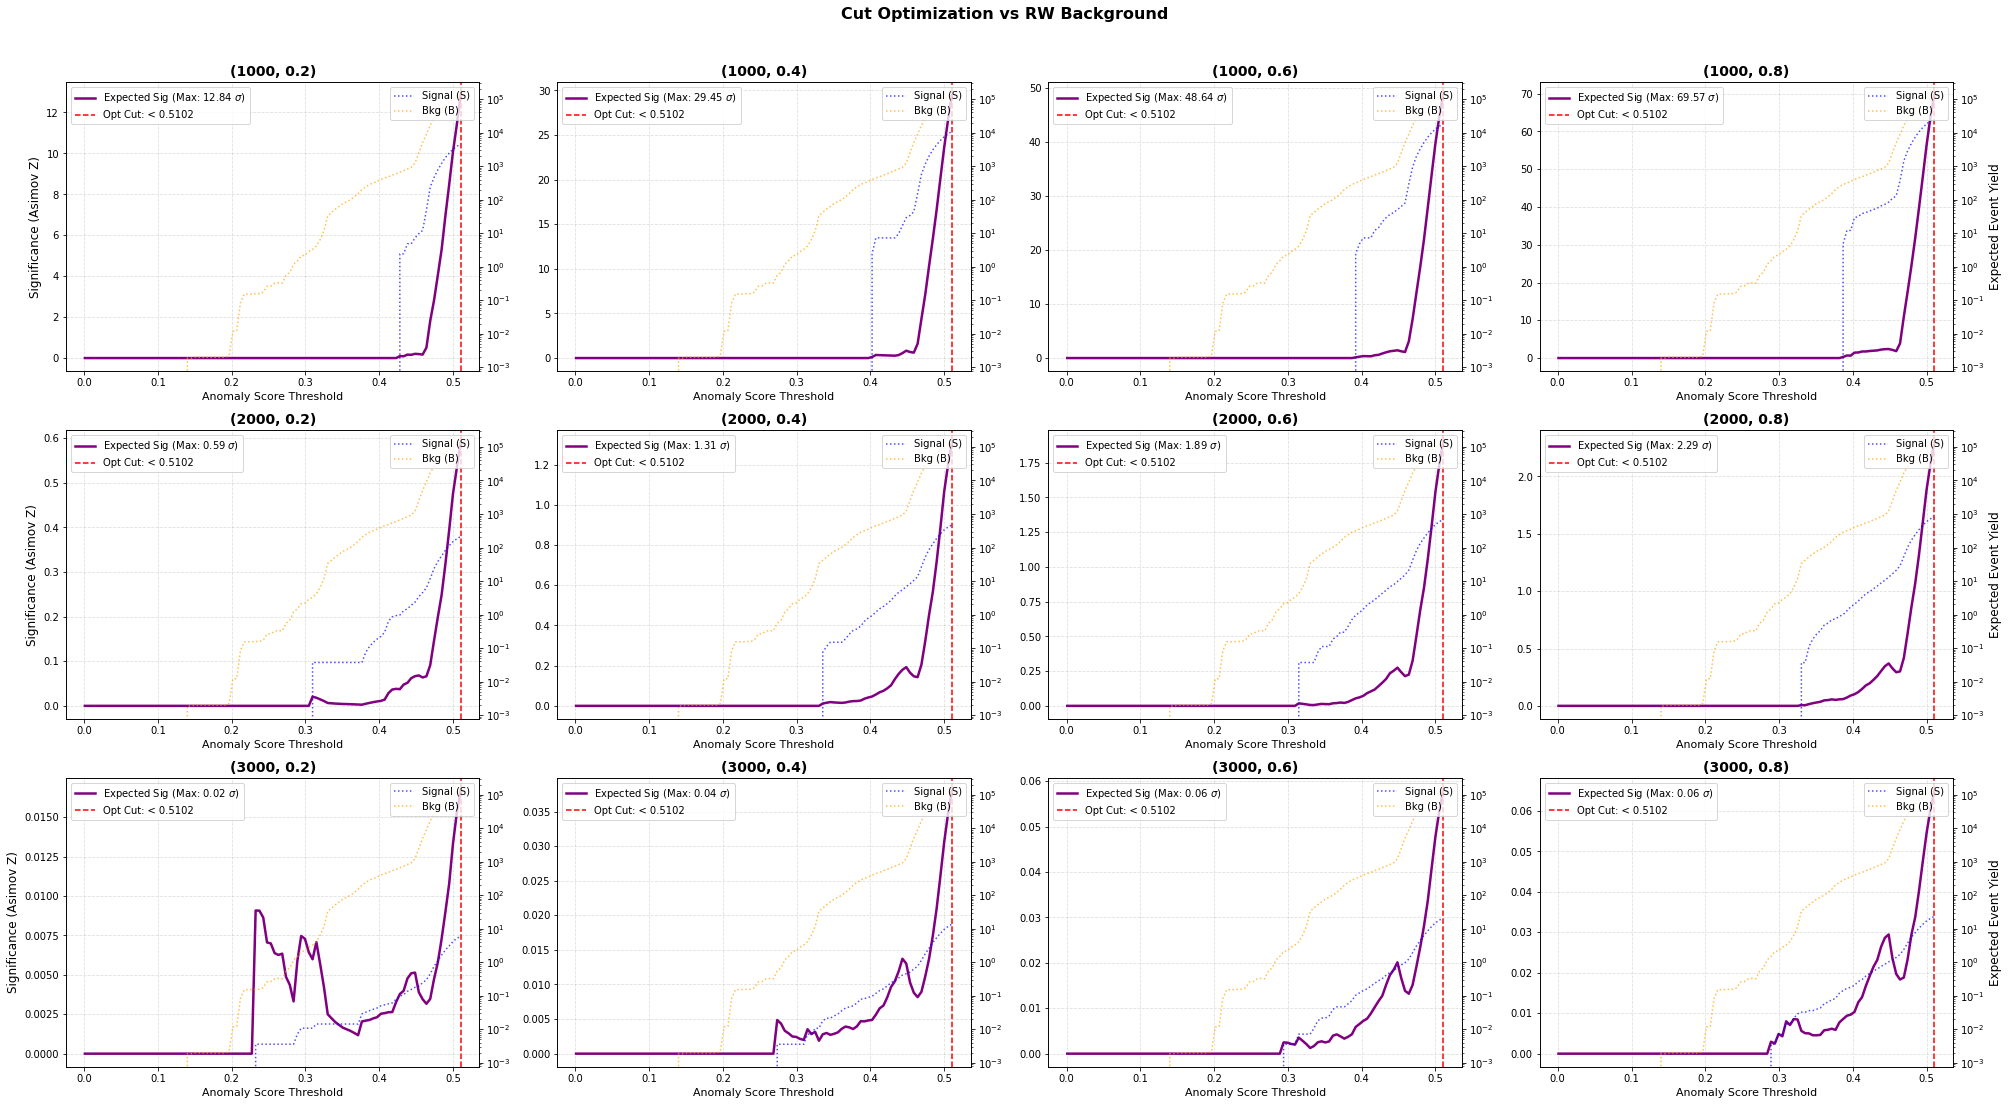

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs RW
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.5102
  Max Significance  : 12.84 sigma
  Expected Signal   : 4652.56
  Expected Bkg      : 129826.32
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.5102
  Max Significance  : 29.45 sigma
  Expected Signal   : 10754.69
  Expected Bkg      : 129826.32
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.5102
  Max Significance  : 48.64 sigma
  Expected Signal   : 17913.89
  Expected Bkg      : 129826.32
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.5102
  Max Significance  : 69.57 sigma
  Expected Signal   : 25860.28
  Expected Bkg      : 129826.32
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.5102
  Max Significance  : 0.59 sigma
  Expected Signal   : 212.20
  Expected Bkg      : 129826.32
--

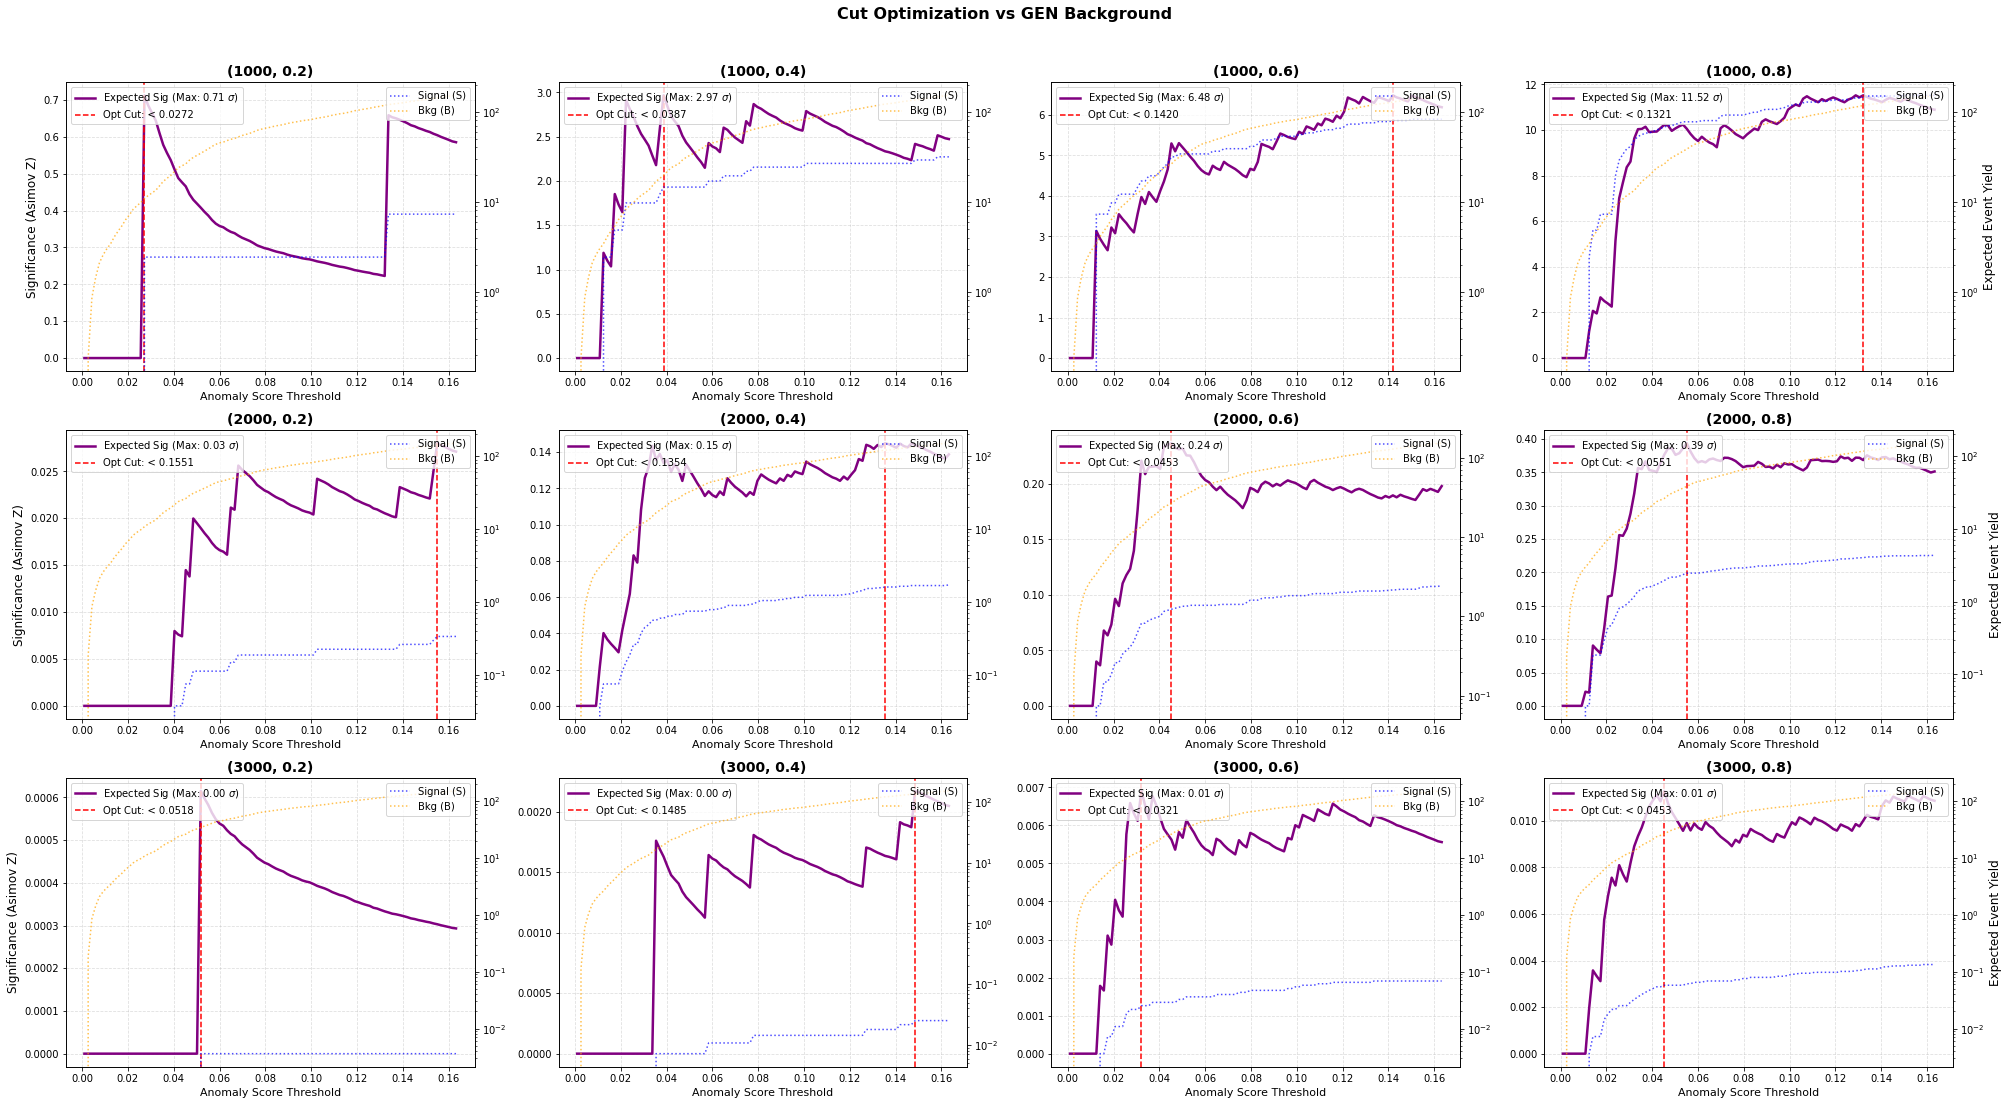

-------------------------------------------------------
OPTIMAL CUT SUMMARY vs GEN
-------------------------------------------------------
Signal (1000, 0.2):
  Optimal Threshold : < 0.0272
  Max Significance  : 0.71 sigma
  Expected Signal   : 2.42
  Expected Bkg      : 10.79
------------------------------
Signal (1000, 0.4):
  Optimal Threshold : < 0.0387
  Max Significance  : 2.97 sigma
  Expected Signal   : 14.53
  Expected Bkg      : 19.59
------------------------------
Signal (1000, 0.6):
  Optimal Threshold : < 0.1420
  Max Significance  : 6.48 sigma
  Expected Signal   : 80.02
  Expected Bkg      : 127.82
------------------------------
Signal (1000, 0.8):
  Optimal Threshold : < 0.1321
  Max Significance  : 11.52 sigma
  Expected Signal   : 145.51
  Expected Bkg      : 117.65
------------------------------
Signal (2000, 0.2):
  Optimal Threshold : < 0.1551
  Max Significance  : 0.03 sigma
  Expected Signal   : 0.33
  Expected Bkg      : 142.25
------------------------------
Sig

In [20]:
opt_cut_results = {}
# bkg_type = "RW" # NOM, RW, GEN

for bkg_type in ["NOM", "RW", "GEN"]:
    # for sig_mode in SIGNAL_MODES:
    if bkg_type == "GEN":
        df_mc = df_mc_gen
        max_cut = gen_cut
    else:
        df_mc = df_mc_rw
        max_cut = rw_cut
        
    opt_cut_results[f"{bkg_type}_{detector_type}"] = optimize_cut_threshold(df_sig_def, df_mc, bkg_type, SIGNAL_MODES, thres_max=max_cut)


## Phase 1 (No BSM Model)

#### Deviation of Data from Background 

In [ ]:
import pyhf
import numpy as np
import scipy.stats

# Optional: Set the pyhf backend to use NumPy for simple CPU execution
pyhf.set_backend("numpy")

def calculate_agnostic_deviation(data_counts, bkg_counts, bkg_stat_unc):
    """
    Calculates the statistical deviation of Data from Background 
    using a model-agnostic generic signal in pyhf.
    """
    
    # 1. Define the Generic Signal (The Data Excess)
    # We cap the minimum at 1e-6 to avoid pyhf errors with absolute zero yields
    generic_signal = [max(d - b, 1e-6) for d, b in zip(data_counts, bkg_counts)]
    
    # If there is absolutely no excess anywhere, return 0 significance
    if sum(generic_signal) <= len(generic_signal) * 1e-6:
        print("No data excess found over background.")
        return 0.5, 0.0, generic_signal

    # 2. Build the pyhf workspace dictionary
    workspace_dict = {
        "channels": [
            {
                "name": "anomaly_region",
                "samples": [
                    {
                        "name": "Generic_Anomaly",
                        "data": generic_signal,
                        "modifiers": [
                            # The signal strength parameter we will test
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    },
                    {
                        "name": "Background",
                        "data": bkg_counts,
                        "modifiers": [
                            # staterror automatically handles independent bin-by-bin 
                            # statistical uncertainties based on your MC weights
                            {
                                "name": "bkg_stat_unc",
                                "type": "staterror",
                                "data": bkg_stat_unc
                            }
                        ]
                    }
                ]
            }
        ],
        "observations": [
            {"name": "anomaly_region", "data": data_counts}
        ],
        "measurements": [
            {"name": "agnostic_test", "config": {"poi": "mu", "mparameters": []}}
        ],
        "version": "1.0.0"
    }

    # 3. Initialize Workspace and Model
    ws = pyhf.Workspace(workspace_dict)
    model = ws.model()
    data = ws.data(model)

    # 4. Perform the Hypothesis Test
    # Testing mu=0 (Background-Only Hypothesis) using the q0 test statistic for discovery
    try:
        result = pyhf.infer.hypotest(
            0.0, data, model, test_stat="q0", return_tail_probs=True
        )
        p0_value = result[1] # result is (CLs_obs, p0_obs) when return_tail_probs=True
    except Exception as e:
        print(f"pyhf fit failed: {e}")
        return None, None, generic_signal

    # 5. Convert p0-value to Gaussian standard deviations (sigma)
    if p0_value < 0.5:
        significance = scipy.stats.norm.isf(p0_value)
    else:
        significance = 0.0

    print("=" * 45)
    print("      MODEL-AGNOSTIC DEVIATION RESULTS     ")
    print("=" * 45)
    print(f"Total Data Events    : {sum(data_counts)}")
    print(f"Total Expected Bkg   : {sum(bkg_counts):.2f}")
    print(f"Integrated Excess    : {sum(generic_signal):.2f}")
    print("-" * 45)
    print(f"Null p0-value        : {p0_value:.4e}")
    print(f"Global Significance  : {significance:.2f} sigma")
    print("=" * 45)

    return p0_value, significance, generic_signal


In [83]:
def get_poisson_errors(counts):
    """
    Returns asymmetric Garwood/Poisson errors (68.27% CL) for an array of counts.
    Returns an array of shape (2, N) for [error_down, error_up].
    """
    alpha = 1 - 0.682689492 # 1-sigma interval
    lower = np.zeros_like(counts, dtype=float)
    upper = np.zeros_like(counts, dtype=float)
    
    # Lower bound is 0 for 0 counts, otherwise calculated via chi2
    mask = counts > 0
    lower[mask] = 0.5 * stats.chi2.ppf(alpha / 2, 2 * counts[mask])
    
    # Upper bound is well-defined for all counts, including 0
    upper = 0.5 * stats.chi2.ppf(1 - alpha / 2, 2 * (counts + 1))
    
    # Matplotlib error bars require relative distances from the central value
    err_down = counts - lower
    err_up = upper - counts
    
    return np.vstack([err_down, err_up])

In [92]:
def plot_all_features_post_cut(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, bkg_type, closure):
    # 1. Apply the cut
    if closure == "HIGH":
        mask_data = df_data[score_col_data] > threshold
        mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    print(f"Data passing cut: {mask_data.sum()}")
    print(f"Bkg passing cut:  {mask_bkg.sum()}")

    # 2. Features mapping
    features = {
        'mjj':           {"bins": np.linspace(0, 4000, 21), "label": "Invariant Mass $m_{jj}$ [GeV]", "log": True, "unit": "GeV"},
        'met_recalc_pt': {"bins": np.linspace(400, 4000, 21), "label": "$E_{T}^{\\mathrm{miss}}$ [GeV]", "log": True, "unit": "GeV"},
        'ht':            {"bins": np.linspace(400, 4000, 21), "label": "$H_T$ [GeV]", "log": True, "unit": "GeV"},
        'ljet1_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet1_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Leading Jet $\\tau_{32}$", "log": False, "unit": None},
        'ljet2_tau21':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{21}$", "log": False, "unit": None},
        'ljet2_tau32':   {"bins": np.linspace(0, 1, 21),      "label": "Subleading Jet $\\tau_{32}$", "log": False, "unit": None}
    }

    fig = plt.figure(figsize=(8*10, 8))
    outer_grid = gridspec.GridSpec(1, 8, wspace=0.3, hspace=0.3)

    for i, (feat, info) in enumerate(features.items()):
        bins = info["bins"]
        bin_width = bins[1] - bins[0]
        
        # Clip data to max/min bin edges (Handle Overflow)
        data_var = np.clip(df_data.loc[mask_data, feat], bins[0], bins[-1])
        bkg_var = np.clip(df_bkg.loc[mask_bkg, feat], bins[0], bins[-1])
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _  = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        

        bkg_stat_unc = np.sqrt(bkg_var_counts)
        data_poisson_err = get_poisson_errors(data_counts) # NEW: Asymmetric data errors

        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], height_ratios=[3, 1], hspace=0.08)
        ax_main = fig.add_subplot(inner_grid[0])
        ax_ratio = fig.add_subplot(inner_grid[1], sharex=ax_main)
        
        # --- Main Plot ---
        hep.histplot(bkg_counts, bins=bins, ax=ax_main, histtype='fill', 
                     color='cornflowerblue', label=f'Expected {bkg_type}', edgecolor='black')
        
        ax_main.stairs(
            values=bkg_counts + bkg_stat_unc, 
            baseline=bkg_counts - bkg_stat_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4, label='Bkg Stat Unc'
        )

        hep.histplot(data_counts, bins=bins, ax=ax_main, histtype='errorbar', 
                     color='black', label='Data', yerr=data_poisson_err) 

        ylabel = f"Events / {bin_width:.2g} {info['unit']}" if info['unit'] else f"Events / {bin_width:.2g}"
        ax_main.set_ylabel(ylabel)
        ax_main.legend(loc='upper right', frameon=False, fontsize=14)
        ax_main.tick_params(labelbottom=False)
        
        if info["log"]:
            ax_main.set_yscale('log')
            ax_main.set_ylim(0.1, max(np.max(data_counts), np.max(bkg_counts)) * 10)
        else:
            ax_main.set_ylim(0, max(np.max(data_counts), np.max(bkg_counts)) * 1.5)
            
        region_text = (
            "SR $E_{T}^{\\mathrm{miss}} > 600$ GeV, $H_T > 600$ GeV\n"
            f"Score {'>' if closure=='HIGH' else '<'} {threshold:.2f}"
        )
        ax_main.text(0.05, 0.95, region_text, transform=ax_main.transAxes, 
                     fontsize=14, verticalalignment='top')

        ratio = np.divide(data_counts, bkg_counts, out=np.ones_like(data_counts, dtype=float), where=(bkg_counts>0))

        ratio_poisson_err = np.zeros_like(data_poisson_err)
        valid_bkg = bkg_counts > 0
        ratio_poisson_err[0, valid_bkg] = data_poisson_err[0, valid_bkg] / bkg_counts[valid_bkg] # Down errors
        ratio_poisson_err[1, valid_bkg] = data_poisson_err[1, valid_bkg] / bkg_counts[valid_bkg] # Up errors
        
        hep.histplot(ratio, bins=bins, ax=ax_ratio, histtype='errorbar', color='black', yerr=ratio_poisson_err)
        
        rel_bkg_unc = np.divide(bkg_stat_unc, bkg_counts, out=np.zeros_like(bkg_stat_unc, dtype=float), where=(bkg_counts>0))
        ax_ratio.stairs(
            values=1 + rel_bkg_unc, 
            baseline=1 - rel_bkg_unc, 
            edges=bins, 
            fill=True, hatch='////', color='gray', alpha=0.4
        )
        
        ax_ratio.axhline(1, color='black', linestyle='--', linewidth=1)
        ax_ratio.set_xlabel(info["label"])
        ax_ratio.set_ylabel("Data / Bkg", fontsize=14)
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.5, 0.75, 1.0, 1.25, 1.5])

    plt.tight_layout()
    plt.show()

def plot_coarse_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the EXACT coarse bin edges for each feature
    features = {
        'mjj': {
            'bins': np.array([400, 1000, 2000, 3000, 4000]), 
            'log': True, 
            'title': 'Invariant Mass $m_{jj}$ [GeV]'
        },
        'ljet1_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{21}$'
        },
        'ljet1_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Leading Jet $\\tau_{32}$'
        },
        'ljet2_tau21': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{21}$'
        },
        'ljet2_tau32': {
            'bins': np.array([0.0, 0.5, 1.0]), 
            'log': False, 
            'title': 'Subleading Jet $\\tau_{32}$'
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        bins = info['bins']
        
        # Extract filtered feature arrays
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Calculate histograms using the DIRECT coarse bin edges
        data_counts, _ = np.histogram(data_var, bins=bins)
        bkg_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights)
        bkg_var_counts, _ = np.histogram(bkg_var, bins=bins, weights=bkg_weights**2)
        bkg_stat_unc = np.sqrt(bkg_var_counts)
        
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_widths = np.diff(bins)
        
        # 1. Plot Expected Background as wide blocks matching coarse bin widths
        ax.bar(bin_centers, bkg_counts, width=bin_widths, color='cornflowerblue', 
               alpha=0.7, edgecolor='navy', label='Expected Bkg')
        
        # 2. Background MC Uncertainty band
        ax.bar(bin_centers, 2 * bkg_stat_unc, width=bin_widths, bottom=bkg_counts - bkg_stat_unc, 
               alpha=0.3, color='gray', hatch='////', label='MC Stat. Unc.')
        
        # 3. Plot Data as points centered inside each coarse bin block
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', capsize=0, elinewidth=1.5, markersize=5)
        
        # Set explicit tick marks on the axis showing exact bin boundaries
        ax.set_xticks(bins)
        
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events / Bin")
        
        # Y-axis scaling
        if info['log']:
            ax.set_yscale('log')
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 10
            min_y = max(0.1, np.min(bkg_counts[bkg_counts > 0]) * 0.5) if len(bkg_counts[bkg_counts > 0]) > 0 else 0.1
            ax.set_ylim(min_y, max_y)
        else:
            max_y = max(np.max(data_counts), np.max(bkg_counts)) * 1.3
            ax.set_ylim(0, max_y)
            
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.4)

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

def visualize_5d_major_blocks(df_data, df_bkg, threshold, score_col_data, score_col_bkg, bkg_weight_col, closure):
    # 1. Apply the ML Filter
    if closure == "HIGH":
            mask_data = df_data[score_col_data] > threshold
            mask_bkg = df_bkg[score_col_bkg] > threshold
    elif closure == "LOW":
        mask_data = df_data[score_col_data] < threshold
        mask_bkg = df_bkg[score_col_bkg] < threshold
    
    # 2. Define the features and their major block boundaries (the coarse bins)
    features = {
        'mjj': {
            'edges': [400, 1000, 2000, 3000, 4000], 
            'plot_range': (400, 4000), 'log': True, 'title': 'Invariant Mass $m_{jj}$',
            'bins': np.arange(0, 4200, 200)
        },
        'ljet1_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet1_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Leading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau21': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{21}$',
            'bins': np.arange(0, 1.25, 0.25)
        },
        'ljet2_tau32': {
            'edges': [0.0, 0.5, 1.0], 
            'plot_range': (0, 1), 'log': False, 'title': 'Subleading Jet $\\tau_{32}$',
            'bins': np.arange(0, 1.25, 0.25)
        }
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (feat, info) in enumerate(features.items()):
        ax = axes[i]
        
        # We use fine binning just for the visual background/data shapes
        fine_bins = info['bins']
        
        # Extract data
        data_var = df_data.loc[mask_data, feat]
        bkg_var = df_bkg.loc[mask_bkg, feat]
        bkg_weights = df_bkg.loc[mask_bkg, bkg_weight_col]
        
        # Plot Expected Background
        ax.hist(bkg_var, bins=fine_bins, weights=bkg_weights, 
                color='cornflowerblue', alpha=0.7, label='Expected Bkg')
        
        # Plot Observed Data
        data_counts, _ = np.histogram(data_var, bins=fine_bins)
        bin_centers = (fine_bins[:-1] + fine_bins[1:]) / 2
        ax.errorbar(bin_centers, data_counts, yerr=np.sqrt(data_counts), 
                    fmt='ko', label='Observed Data', markersize=4)
        
        # Overlay the Major Block Bin Boundaries
        for edge in info['edges']:
            ax.axvline(edge, color='red', linestyle='--', linewidth=2, alpha=0.8)
            
        ax.set_title(info['title'], fontsize=12, fontweight='bold')
        ax.set_ylabel("Events")
        if info['log']:
            ax.set_yscale('log')
        ax.legend()

    # Hide the 6th empty subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

Data passing cut: 186199
Bkg passing cut:  5284063


/tmp/ipykernel_408129/1805124053.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


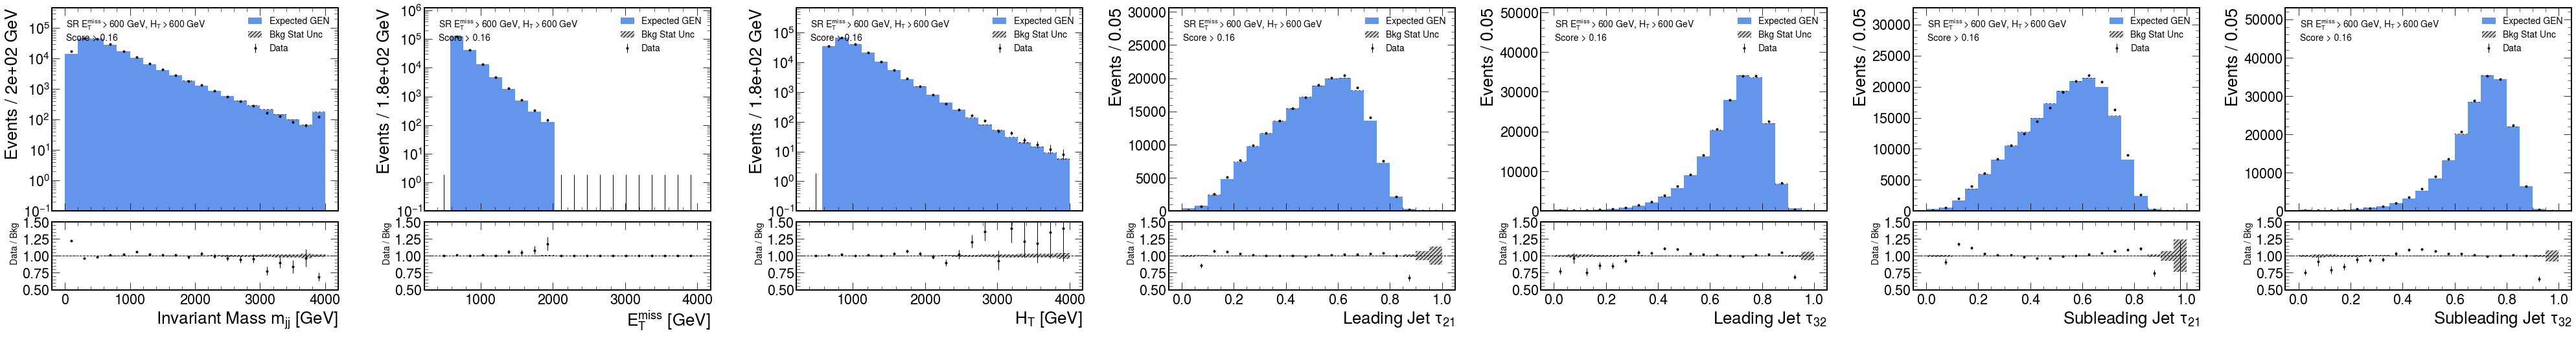

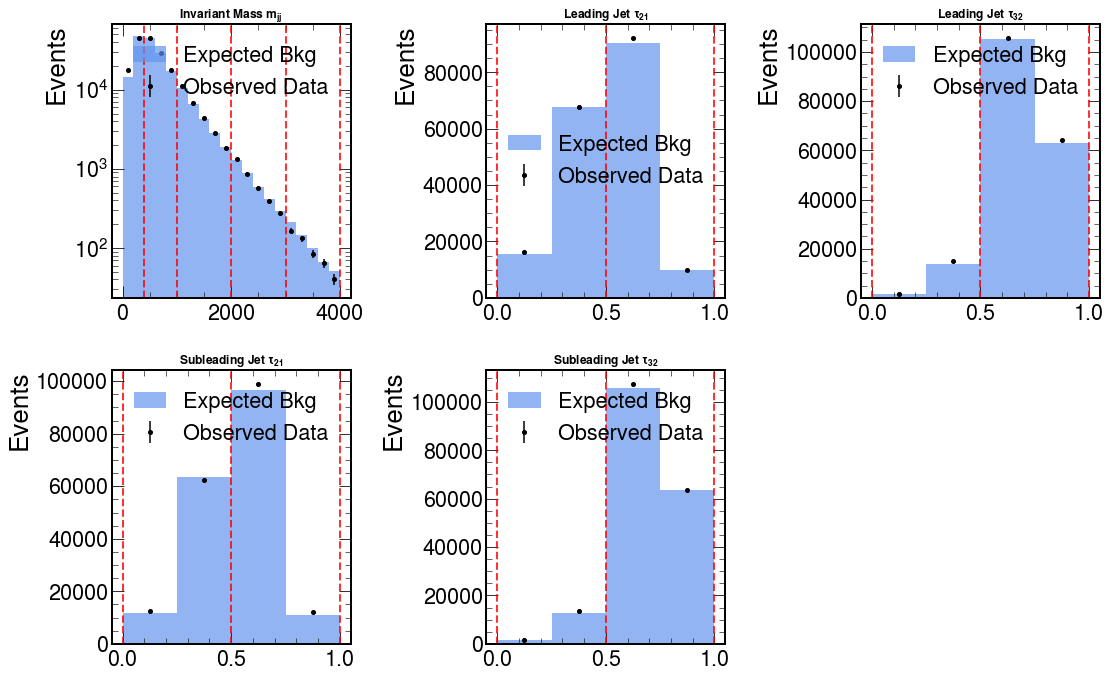

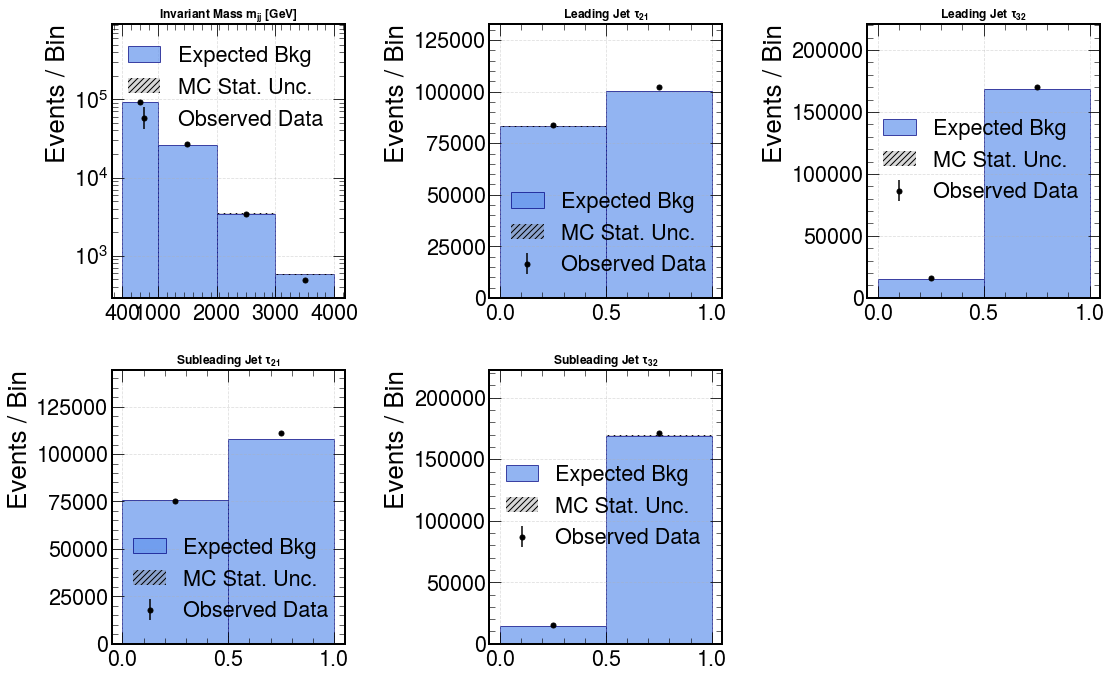

In [93]:
bkg_type = "GEN"
closure = "HIGH"
if bkg_type == "NOM":
    data_col_score = "score_vs_nominal"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Nom"
    bkg_weight_name = "final_weight"
    anomaly_threshold = nom_cut
    df_bkg = df_mc_rw
elif bkg_type == "RW":
    data_col_score = "score_vs_reweighted"
    bkg_col_score = "score_vs_reweighted_data"
    sig_col_score = "bsm_score_Reweight_Median"
    bkg_weight_name = "rw_mediam_weights"
    anomaly_threshold = rw_cut
    df_bkg = df_mc_rw
elif bkg_type == "GEN":
    data_col_score = "score_vs_generate"
    bkg_col_score = "score_vs_data"
    sig_col_score = "bsm_score_Generate_Combined"
    bkg_weight_name = "total_weight"
    anomaly_threshold = gen_cut
    df_bkg = df_mc_gen
else:
    raise ValueError("Invalid bkg_type. Choose from 'NOM', 'RW', 'GEN'.")


df_data_unscaled = transform(df_data, scale=False)
df_bkg_unscaled = transform(df_bkg, scale=False)


plot_all_features_post_cut(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    bkg_type=bkg_type,
    closure = closure
)

visualize_5d_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)

plot_coarse_major_blocks(
    df_data=df_data_unscaled, 
    df_bkg=df_bkg_unscaled, 
    threshold=anomaly_threshold, 
    score_col_data=data_col_score, 
    score_col_bkg=bkg_col_score, 
    bkg_weight_col=bkg_weight_name,
    closure = closure
)



# # 3. Run the Agnostic Deviation Test
# p0, sigma, gen_sig = calculate_agnostic_deviation(
#     data_counts=data_counts_list, 
#     bkg_counts=bkg_counts_list, 
#     bkg_stat_unc=bkg_stat_unc_list
# )